# Data audit: intraday returns and missingness

This notebook audits the dataset before any model is trained. It keeps observed zero returns distinct from missing observations.

---

## Panel structure audit

This section treats `day` as a panel identifier only. Its numerical properties are audited below, but no chronological ordering, calendar spacing, or temporal continuity is assumed.

In [1]:
from pathlib import Path
import itertools
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Open this notebook from the project or notebooks directory.')

sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import (
    ReturnPreprocessor,
    get_return_columns,
    load_training_data,
    summarize_missingness,
)

X_train, y_train = load_training_data(PROJECT_ROOT / 'data')
return_columns = get_return_columns(X_train.columns)
returns = X_train[return_columns]


N_DAYS = X_train['day'].nunique()
N_EQUITIES = X_train['equity'].nunique()
N_ROWS = len(X_train)
N_OBSERVED_PAIRS = X_train[['day', 'equity']].drop_duplicates().shape[0]
N_DUPLICATE_ROWS_PER_PAIR = N_ROWS - N_OBSERVED_PAIRS
PANEL_DENSITY = N_OBSERVED_PAIRS / (N_DAYS * N_EQUITIES)

panel_overview = pd.Series({
    'rows': N_ROWS,
    'unique_days': N_DAYS,
    'unique_equities': N_EQUITIES,
    'observed_day_equity_pairs': N_OBSERVED_PAIRS,
    'duplicate_rows_per_day_equity_pair': N_DUPLICATE_ROWS_PER_PAIR,
    'theoretical_day_equity_pairs': N_DAYS * N_EQUITIES,
    'observed_panel_density': PANEL_DENSITY,
}, name='value').to_frame()
display(panel_overview)

,value
rows,843299.000000
unique_days,503.000000
unique_equities,1829.000000
observed_day_equity_pairs,843299.000000
duplicate_rows_per_day_equity_pair,0.000000
theoretical_day_equity_pairs,919987.000000
observed_panel_density,0.916642


,observations_per_day,observations_per_equity,distinct_days_per_equity,equity_day_coverage
count,503.000000,1829.000000,1829.000000,1829.000000
mean,1676.538767,461.071077,461.071077,0.916642
std,16.061076,108.499712,108.499712,0.215705
min,1633.000000,3.000000,3.000000,0.005964
1%,1634.000000,36.000000,36.000000,0.071571
10%,1648.000000,304.400000,304.400000,0.605169
25%,1671.000000,503.000000,503.000000,1.000000
50%,1680.000000,503.000000,503.000000,1.000000
75%,1687.000000,503.000000,503.000000,1.000000
90%,1693.000000,503.000000,503.000000,1.000000


,value
equities_present_on_one_day,0.000000
share_equities_present_on_one_day,0.000000
equities_present_on_all_day_ids,1513.000000
share_equities_present_on_all_day_ids,0.827228


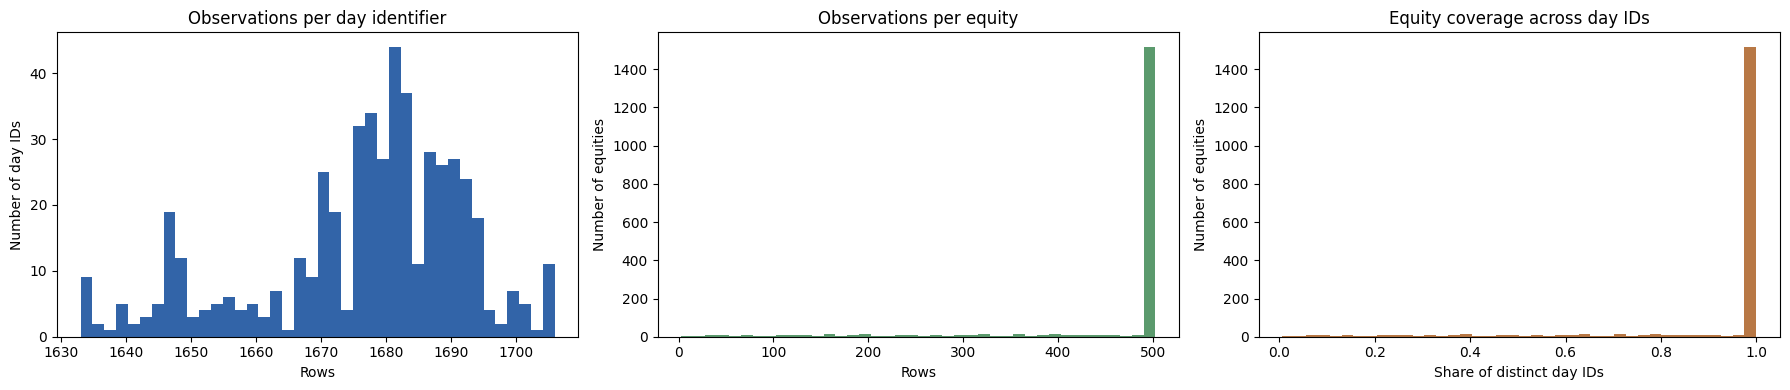

In [2]:
def compact_describe(values: pd.Series) -> pd.Series:
    return values.describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])

observations_per_day = X_train.groupby('day').size().rename('observations')
observations_per_equity = X_train.groupby('equity').size().rename('observations')
days_per_equity = X_train.groupby('equity')['day'].nunique().rename('distinct_days')
equity_coverage = (days_per_equity / N_DAYS).rename('day_coverage')

entity_summary = pd.concat({
    'observations_per_day': compact_describe(observations_per_day),
    'observations_per_equity': compact_describe(observations_per_equity),
    'distinct_days_per_equity': compact_describe(days_per_equity),
    'equity_day_coverage': compact_describe(equity_coverage),
}, axis=1)
display(entity_summary)

coverage_summary = pd.Series({
    'equities_present_on_one_day': int((days_per_equity == 1).sum()),
    'share_equities_present_on_one_day': float((days_per_equity == 1).mean()),
    'equities_present_on_all_day_ids': int((days_per_equity == N_DAYS).sum()),
    'share_equities_present_on_all_day_ids': float((days_per_equity == N_DAYS).mean()),
}, name='value').to_frame()
display(coverage_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(observations_per_day, bins=40, color='#3264a8')
axes[0].set(title='Observations per day identifier', xlabel='Rows', ylabel='Number of day IDs')
axes[1].hist(observations_per_equity, bins=40, color='#5b9a6d')
axes[1].set(title='Observations per equity', xlabel='Rows', ylabel='Number of equities')
axes[2].hist(equity_coverage, bins=40, color='#b87845')
axes[2].set(title='Equity coverage across day IDs', xlabel='Share of distinct day IDs', ylabel='Number of equities')
plt.tight_layout()
plt.show()

Jaccard method: reproducible sample of 10,000 unordered day-ID pairs from 126,253 possible pairs (seed=20260908)


,jaccard_overlap
count,10000.000000
mean,0.938299
std,0.040897
min,0.838656
1%,0.848030
10%,0.877884
25%,0.907168
50%,0.943320
75%,0.973486
90%,0.989318


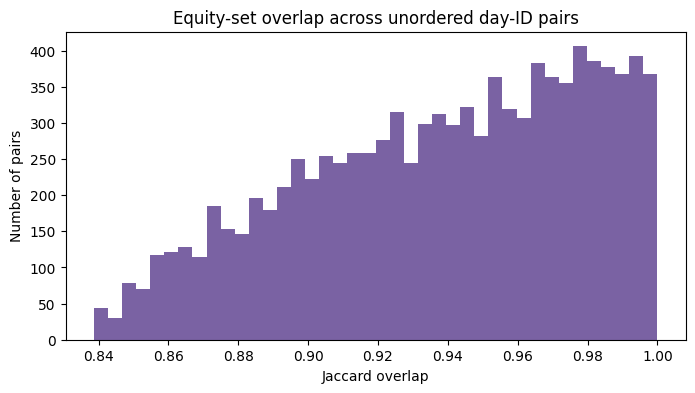

In [3]:
# Cross-identifier membership overlap. This does not assume that day IDs are chronological.
equities_by_day = X_train.groupby('day')['equity'].agg(lambda values: set(values)).sort_index()
day_sets = equities_by_day.tolist()
n_possible_day_pairs = N_DAYS * (N_DAYS - 1) // 2
max_exact_pairs = 50_000
max_sample_pairs = 10_000

if n_possible_day_pairs <= max_exact_pairs:
    day_pair_indices = list(itertools.combinations(range(N_DAYS), 2))
    jaccard_method = f'exact calculation over all {n_possible_day_pairs:,} unordered day-ID pairs'
else:
    rng = np.random.default_rng(20260908)
    sampled = set()
    target_pairs = min(max_sample_pairs, n_possible_day_pairs)
    while len(sampled) < target_pairs:
        pair = tuple(sorted(rng.choice(N_DAYS, size=2, replace=False)))
        sampled.add(pair)
    day_pair_indices = list(sampled)
    jaccard_method = (
        f'reproducible sample of {target_pairs:,} unordered day-ID pairs '
        f'from {n_possible_day_pairs:,} possible pairs (seed=20260908)'
    )

jaccard_values = []
for left, right in day_pair_indices:
    left_set, right_set = day_sets[left], day_sets[right]
    jaccard_values.append(len(left_set & right_set) / len(left_set | right_set))

jaccard_values = pd.Series(jaccard_values, name='jaccard_overlap')
print('Jaccard method:', jaccard_method)
display(compact_describe(jaccard_values).to_frame())
ax = jaccard_values.plot.hist(bins=40, color='#7a62a3', figsize=(8, 4))
ax.set(title='Equity-set overlap across unordered day-ID pairs', xlabel='Jaccard overlap', ylabel='Number of pairs')
plt.show()

,count,proportion
reod,,
-1,253639,0.300770
0,347465,0.412031
1,242195,0.287199


day_class_counts                           day_class_proportions  \
reod                -1            0            1                    -1   
count       503.000000   503.000000   503.000000            503.000000   
mean        504.252485   690.785288   481.500994              0.300850   
std         285.534938   186.445504   258.916389              0.170767   
min           0.000000   131.000000     0.000000              0.000000   
1%            0.480000   190.020000     0.400000              0.000285   
10%         218.000000   463.800000   184.800000              0.129546   
50%         445.000000   716.000000   444.000000              0.263971   
90%         879.000000   836.000000   828.200000              0.525477   
99%        1365.000000  1656.420000  1321.200000              0.823832   
max        1536.000000  1706.000000  1496.000000              0.910492   

                              equity_class_counts                            \
reod            0           1                  -1            0            1   
count  503.000000  503.000000         1829.000000  1829.000000  1829.000000   
mean     0.411923    0.287227          138.676326   189.975396   132.419355   
std      0.110625    0.154723           51.664496    85.494878    49.069835   
min      0.077653    0.000000            0.000000     3.000000     0.000000   
1%       0.115303    0.000237            4.280000    14.560000     4.000000   
10%      0.277681    0.109961           63.000000    91.000000    58.000000   
50%      0.426594    0.263593          151.000000   182.000000   144.000000   
90%      0.500648    0.491651          194.200000   304.000000   186.000000   
99%      0.991221    0.800317          222.000000   448.720000   213.000000   
max      1.000000    0.887307          245.000000   499.000000   250.000000   

      equity_class_proportions                            
reod                        -1            0            1  
count              1829.000000  1829.000000  1829.000000  
mean                  0.298881     0.415189     0.285931  
std                   0.088506     0.164207     0.083665  
min                   0.000000     0.105263     0.000000  
1%                    0.031126     0.159168     0.022257  
10%                   0.178926     0.238291     0.172962  
50%                   0.316103     0.383698     0.300199  
90%                   0.395668     0.642545     0.377734  
99%                   0.454712     0.946322     0.429636  
max                   0.533333     1.000000     0.583333

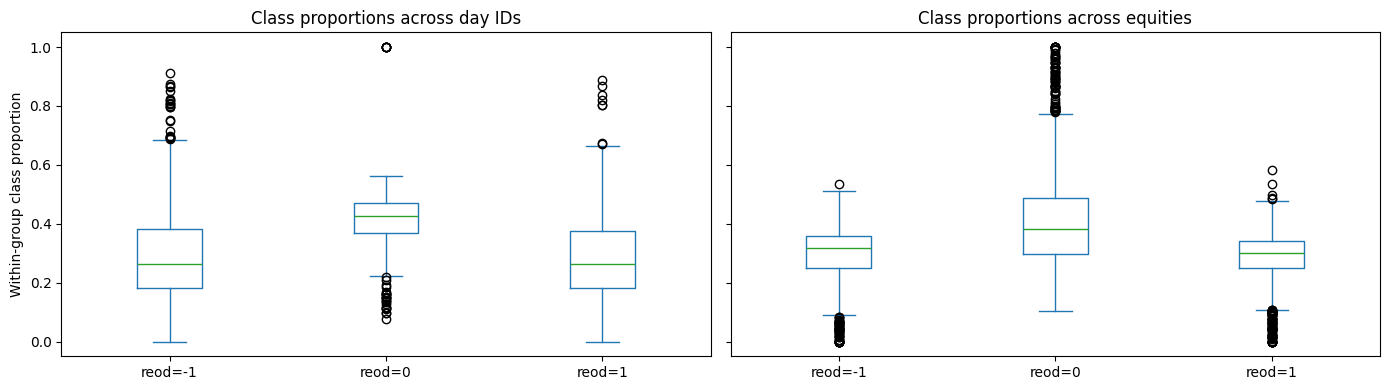

In [4]:
classes = [-1, 0, 1]
global_target_distribution = (
    y_train.value_counts().reindex(classes, fill_value=0).to_frame('count')
    .assign(proportion=lambda frame: frame['count'] / frame['count'].sum())
)
global_target_distribution.index.name = 'reod'
display(global_target_distribution)

def grouped_target_distribution(group_column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    frame = pd.DataFrame({group_column: X_train[group_column], 'reod': y_train})
    counts = pd.crosstab(frame[group_column], frame['reod']).reindex(columns=classes, fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    return counts, proportions

day_target_counts, day_target_proportions = grouped_target_distribution('day')
equity_target_counts, equity_target_proportions = grouped_target_distribution('equity')

target_group_summary = pd.concat({
    'day_class_counts': day_target_counts.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'day_class_proportions': day_target_proportions.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'equity_class_counts': equity_target_counts.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'equity_class_proportions': equity_target_proportions.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
}, axis=1)
display(target_group_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
day_target_proportions.rename(columns={-1: 'reod=-1', 0: 'reod=0', 1: 'reod=1'}).plot.box(ax=axes[0])
axes[0].set(title='Class proportions across day IDs', ylabel='Within-group class proportion')
equity_target_proportions.rename(columns={-1: 'reod=-1', 0: 'reod=0', 1: 'reod=1'}).plot.box(ax=axes[1])
axes[1].set(title='Class proportions across equities')
plt.tight_layout()
plt.show()

In [5]:
# Identifier audit only: numeric gaps do not establish chronological meaning.
sorted_day_ids = np.sort(X_train['day'].unique())
day_id_steps = np.diff(sorted_day_ids)
positive_gaps = day_id_steps[day_id_steps > 1]
missing_integer_ids_within_range = int(sorted_day_ids[-1] - sorted_day_ids[0] + 1 - len(sorted_day_ids))

day_id_summary = pd.Series({
    'minimum_day_id': int(sorted_day_ids[0]),
    'maximum_day_id': int(sorted_day_ids[-1]),
    'unique_day_ids': len(sorted_day_ids),
    'integer_ids_missing_within_range': missing_integer_ids_within_range,
    'number_of_non_unit_gaps': len(positive_gaps),
}, name='value').to_frame()
display(day_id_summary)

if len(positive_gaps):
    display(compact_describe(pd.Series(positive_gaps, name='gap_size')).to_frame())
    ax = pd.Series(positive_gaps).plot.hist(bins=min(40, len(np.unique(positive_gaps))), color='#a85d5d', figsize=(8, 4))
    ax.set(title='Sizes of non-unit gaps between sorted day identifiers', xlabel='Identifier gap size', ylabel='Number of gaps')
    plt.show()
else:
    print('No non-unit gaps were found in the sorted numeric day identifiers.')

print('Interpretation constraint: these are identifier properties only; they do not prove chronological ordering or calendar spacing.')

,value
minimum_day_id,0
maximum_day_id,502
unique_day_ids,503
integer_ids_missing_within_range,0
number_of_non_unit_gaps,0


No non-unit gaps were found in the sorted numeric day identifiers.
Interpretation constraint: these are identifier properties only; they do not prove chronological ordering or calendar spacing.


## Intraday returns and missingness

This notebook validates the preprocessing assumptions before training a classifier. In particular, it keeps observed zero returns distinct from missing observations.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Open this notebook from the project or notebooks directory.')

sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import (
    ReturnPreprocessor,
    get_return_columns,
    load_training_data,
    summarize_missingness,
)

In [7]:
# X_train, y_train and the return columns were initialized above.
print(f'Rows: {len(X_train):,}')
print(f'Return timestamps: {len(return_columns)}')
display(y_train.value_counts().sort_index().rename('count').to_frame())
display(summarize_missingness(returns).head())

Rows: 843,299
Return timestamps: 53


,count
reod,
-1,253639
0,347465
1,242195


,missing_count,missing_ratio,zero_ratio_observed
return_column,,,
r0,45823,0.054338,0.209071
r1,96815,0.114805,0.160788
r2,102470,0.121511,0.166578
r3,94169,0.111667,0.159994
r4,93730,0.111147,0.167140


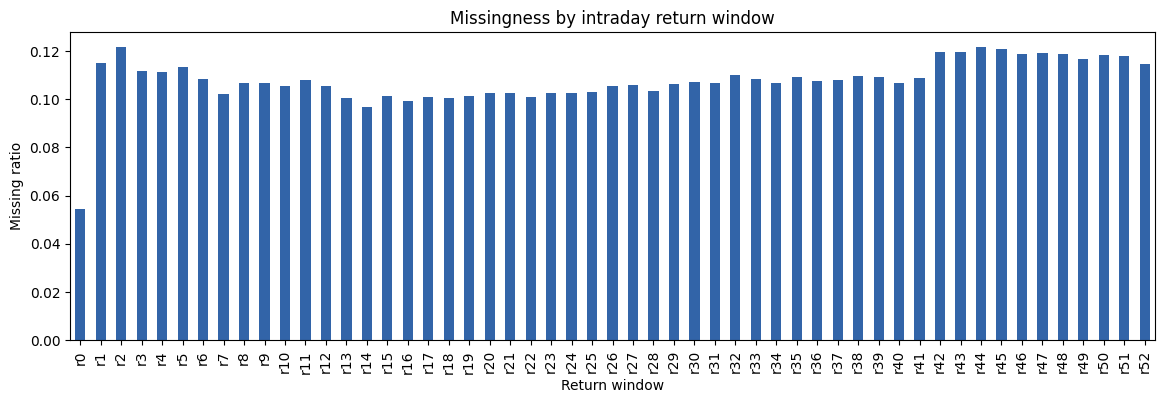

,mean,median,count
reod,,,
-1,0.056461,0.0,253639
0,0.181826,0.0,347465
1,0.054944,0.0,242195


In [8]:
audit = summarize_missingness(returns)
ax = audit['missing_ratio'].plot(kind='bar', figsize=(14, 4), color='#3264a8')
ax.set(title='Missingness by intraday return window', xlabel='Return window', ylabel='Missing ratio')
plt.show()

class_missingness = (
    pd.concat([returns.isna().mean(axis=1).rename('missing_ratio'), y_train], axis=1)
    .groupby('reod')['missing_ratio']
    .agg(['mean', 'median', 'count'])
)
display(class_missingness)

In [9]:
# Baseline representation for tree models: preserve NaNs and add masks.
preprocessor = ReturnPreprocessor(imputation='none', scale=False).fit(X_train)
X_tabular = preprocessor.tabular_inputs(X_train.iloc[:5_000])
sequence_values, observed_mask = preprocessor.sequence_inputs(X_train.iloc[:5_000])

print('Tabular shape:', X_tabular.shape)
print('Sequence values shape:', sequence_values.shape)
print('Observed-mask shape:', observed_mask.shape)

Tabular shape: (5000, 112)
Sequence values shape: (5000, 53)
Observed-mask shape: (5000, 53)


## Decision checkpoint

Before adding a VAE, compare native missing-value handling and median imputation plus masks with leakage-safe validation folds. A more complex imputer is retained only if it improves out-of-fold classification performance, not merely reconstruction error.

---

## Missingness audit: NaN, observed zero, and within-equity association

This is a descriptive training-data audit only. It does not treat `NaN` as zero or as evidence of no trading, does not use competition test data, and does not evaluate a predictive model.

In [10]:
# Q1: each return cell belongs to one and only one state.
return_values = returns.to_numpy(copy=False)
target_values = y_train.to_numpy()
state_names = ['missing', 'observed_zero', 'observed_nonzero']
q1_aggregate_records, q1_position_records = [], []

for label in classes:
    class_values = return_values[target_values == label]
    missing = np.isnan(class_values)
    observed_zero = class_values == 0
    observed_nonzero = (~missing) & (~observed_zero)
    state_arrays = {'missing': missing, 'observed_zero': observed_zero, 'observed_nonzero': observed_nonzero}
    for state, values in state_arrays.items():
        q1_aggregate_records.append({'reod': label, 'state': state, 'count': int(values.sum()), 'share_all_return_cells': float(values.mean())})
        for position, column in enumerate(return_columns):
            q1_position_records.append({'reod': label, 'return_column': column, 'position': position, 'state': state, 'share_all_return_cells': float(values[:, position].mean())})

q1_aggregate = pd.DataFrame(q1_aggregate_records)
q1_position_rates = pd.DataFrame(q1_position_records)
q1_aggregate_table = q1_aggregate.pivot(index='reod', columns='state', values=['count', 'share_all_return_cells'])
q1_state_shares = q1_aggregate.pivot(index='reod', columns='state', values='share_all_return_cells')
q1_observed_zero_given_observed = (q1_state_shares['observed_zero'] / (q1_state_shares['observed_zero'] + q1_state_shares['observed_nonzero'])).rename('observed_zero_given_observed').to_frame()
display(q1_aggregate_table)
display(q1_observed_zero_given_observed)

count                                share_all_return_cells  \
state    missing observed_nonzero observed_zero                missing   
reod                                                                     
-1      758999.0        9843283.0     2840585.0               0.056461   
 0     3348447.0       11216410.0     3850788.0               0.181826   
 1      705274.0        9454160.0     2676901.0               0.054944   

                                      
state observed_nonzero observed_zero  
reod                                  
-1            0.732231      0.211308  
 0            0.609070      0.209104  
 1            0.736516      0.208541

,observed_zero_given_observed
reod,
-1,0.223953
0,0.255574
1,0.220665


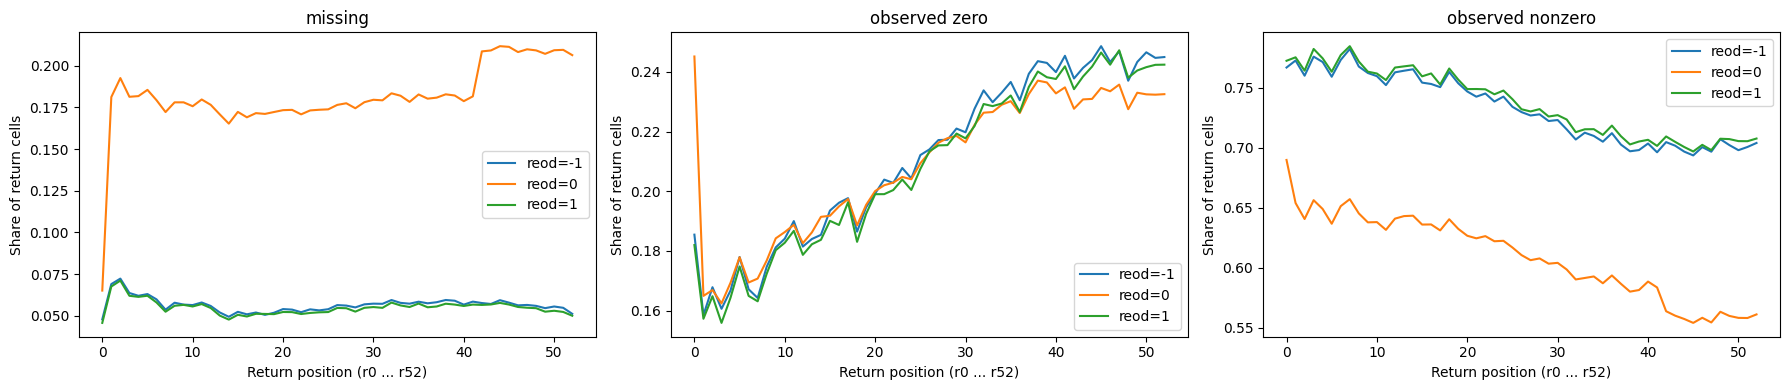

reod                          -1                                        0  \
state                    missing observed_nonzero observed_zero   missing   
return_column position                                                      
r0            0         0.047844         0.766696      0.185460  0.065094   
r1            1         0.068984         0.772543      0.158473  0.181201   
r2            2         0.072272         0.759891      0.167837  0.192604   
r3            3         0.063638         0.775760      0.160602  0.181371   
r4            4         0.061966         0.771277      0.166757  0.181777   

reod                                                          1  \
state                  observed_nonzero observed_zero   missing   
return_column position                                            
r0            0                0.689713      0.245193  0.045707   
r1            1                0.653867      0.164932  0.067536   
r2            2                0.640513      0.166883  0.071083   
r3            3                0.656210      0.162419  0.061967   
r4            4                0.648860      0.169364  0.061322   

reod                                                   
state                  observed_nonzero observed_zero  
return_column position                                 
r0            0                0.772320      0.181973  
r1            1                0.775198      0.157266  
r2            2                0.764095      0.164822  
r3            3                0.782155      0.155879  
r4            4                0.774326      0.164351

In [11]:
# Q1 by intraday position; every rate is relative to all class-position cells.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, state in zip(axes, state_names):
    state_rates = q1_position_rates[q1_position_rates['state'] == state]
    for label in classes:
        subset = state_rates[state_rates['reod'] == label].sort_values('position')
        axis.plot(subset['position'], subset['share_all_return_cells'], label=f'reod={label}')
    axis.set(title=state.replace('_', ' '), xlabel='Return position (r0 ... r52)', ylabel='Share of return cells')
    axis.legend()
plt.tight_layout()
plt.show()

q1_position_summary = q1_position_rates.pivot_table(index=['return_column', 'position'], columns=['reod', 'state'], values='share_all_return_cells').sort_index(level='position')
display(q1_position_summary.head())

In [12]:
# Q2: within-equity contrasts; all eligible equities are retained without a minimum count threshold.
row_missing_ratio = returns.isna().mean(axis=1).rename('missing_ratio')
within_equity_frame = pd.DataFrame({'equity': X_train['equity'], 'reod': y_train, 'missing_ratio': row_missing_ratio})

def within_equity_contrast(name, comparison_mask):
    working = within_equity_frame.loc[(within_equity_frame['reod'] == 0) | comparison_mask].copy()
    working['group'] = np.where(working['reod'] == 0, 'zero', 'comparison')
    grouped = working.groupby(['equity', 'group'])['missing_ratio'].agg(['mean', 'size']).unstack('group')
    grouped.columns = [f'{statistic}_{group}' for statistic, group in grouped.columns]
    eligible = grouped.dropna(subset=['mean_zero', 'mean_comparison']).copy()
    eligible['delta_zero_minus_comparison'] = eligible['mean_zero'] - eligible['mean_comparison']
    eligible['contrast'] = name
    return eligible.reset_index()

contrasts = pd.concat([
    within_equity_contrast('0_vs_nonzero', within_equity_frame['reod'] != 0),
    within_equity_contrast('0_vs_minus_1', within_equity_frame['reod'] == -1),
    within_equity_contrast('0_vs_plus_1', within_equity_frame['reod'] == 1),
], ignore_index=True)

def contrast_summary(frame):
    delta = frame['delta_zero_minus_comparison']
    return pd.Series({'eligible_equities': len(frame), 'mean_delta': delta.mean(), 'median_delta': delta.median(), 'p10_delta': delta.quantile(0.10), 'p90_delta': delta.quantile(0.90), 'share_positive_delta': (delta > 0).mean(), 'mean_n_zero': frame['size_zero'].mean(), 'median_n_zero': frame['size_zero'].median(), 'mean_n_comparison': frame['size_comparison'].mean(), 'median_n_comparison': frame['size_comparison'].median()})

q2_contrast_summary = pd.DataFrame({name: contrast_summary(group) for name, group in contrasts.groupby('contrast')}).T
display(q2_contrast_summary)

primary_sample_sizes = contrasts.loc[contrasts['contrast'] == '0_vs_nonzero', ['size_zero', 'size_comparison']]
display(primary_sample_sizes.describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]))

,eligible_equities,mean_delta,median_delta,p10_delta,p90_delta,share_positive_delta,mean_n_zero,median_n_zero,mean_n_comparison,median_n_comparison
0_vs_minus_1,1821.0,0.044081,0.009008,0.005042,0.140219,0.990664,190.374519,182.0,139.285557,151.0
0_vs_nonzero,1822.0,0.043860,0.009144,0.005074,0.139491,0.992316,190.277717,182.0,272.137212,296.0
0_vs_plus_1,1820.0,0.043435,0.009038,0.005087,0.135456,0.990659,190.460989,182.0,133.074176,144.0


,size_zero,size_comparison
count,1822.000000,1822.000000
mean,190.277717,272.137212
std,85.273535,97.000104
min,4.000000,1.000000
1%,16.210000,14.000000
10%,92.100000,123.000000
25%,137.000000,221.000000
50%,182.000000,296.000000
75%,233.000000,343.000000
90%,304.000000,375.000000


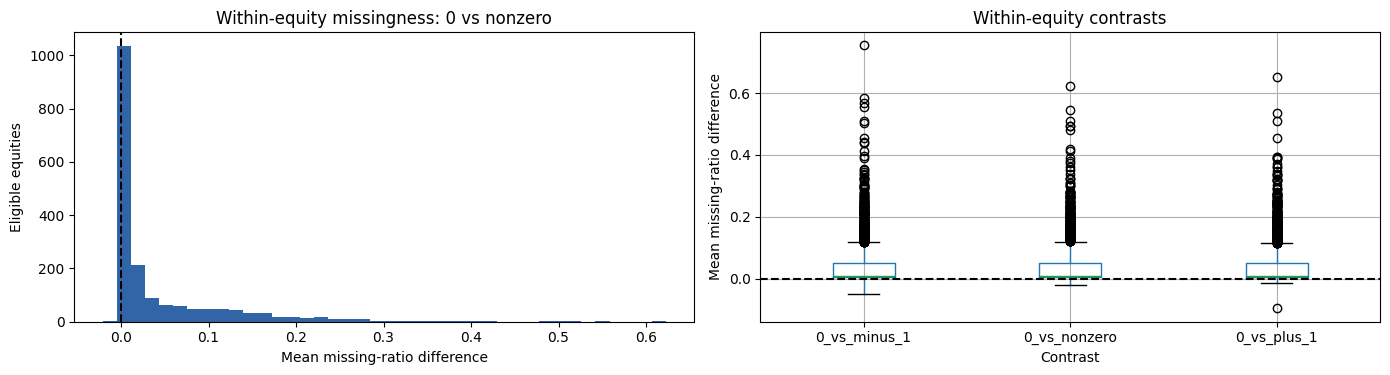

Interpretation boundary: these contrasts describe association within equities. They do not identify liquidity, trading activity, or a technical data-availability mechanism.


In [13]:
# Q2 visual diagnostics. Each primary-contrast observation is one eligible equity.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
primary_delta = contrasts.loc[contrasts['contrast'] == '0_vs_nonzero', 'delta_zero_minus_comparison']
axes[0].hist(primary_delta, bins=40, color='#3264a8')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set(title='Within-equity missingness: 0 vs nonzero', xlabel='Mean missing-ratio difference', ylabel='Eligible equities')
contrasts.boxplot(column='delta_zero_minus_comparison', by='contrast', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set(title='Within-equity contrasts', xlabel='Contrast', ylabel='Mean missing-ratio difference')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Interpretation boundary: these contrasts describe association within equities. They do not identify liquidity, trading activity, or a technical data-availability mechanism.')

---

## Post-EXP_001 descriptive audit: target composition by exact missing count

This is a pooled training-data description, not an OOS evaluation or a new experiment. It preserves every exact `n_missing` level from 0 through 53, where `n_missing` is the number of original `NaN` values in `r0...r52`. Observed zero returns remain observed values.

In [14]:
# Exact missing-count table: no bins, smoothing, thresholds, or post-hoc grouping.
missing_count_levels = pd.Index(range(54), name='n_missing')
n_missing = returns.isna().sum(axis=1).astype('int8').rename('n_missing')
assert n_missing.between(0, 53).all()

missing_count_class_counts = (
    pd.crosstab(n_missing, y_train)
    .reindex(index=missing_count_levels, columns=classes, fill_value=0)
)
missing_count_probabilities = missing_count_class_counts.div(
    missing_count_class_counts.sum(axis=1).replace(0, np.nan), axis=0
)

missing_count_exact_table = pd.DataFrame({
    'n_rows': missing_count_class_counts.sum(axis=1),
    'count_reod_-1': missing_count_class_counts[-1],
    'count_reod_0': missing_count_class_counts[0],
    'count_reod_1': missing_count_class_counts[1],
    'p_reod_-1_given_n_missing': missing_count_probabilities[-1],
    'p_reod_0_given_n_missing': missing_count_probabilities[0],
    'p_reod_1_given_n_missing': missing_count_probabilities[1],
})
missing_count_exact_table['p_directional_given_n_missing'] = (
    missing_count_exact_table['p_reod_-1_given_n_missing']
    + missing_count_exact_table['p_reod_1_given_n_missing']
)
missing_count_exact_table['p_minus_1_minus_p_plus_1'] = (
    missing_count_exact_table['p_reod_-1_given_n_missing']
    - missing_count_exact_table['p_reod_1_given_n_missing']
)

nonempty_missing_levels = missing_count_exact_table['n_rows'] > 0
assert (
    missing_count_exact_table.loc[nonempty_missing_levels, ['count_reod_-1', 'count_reod_0', 'count_reod_1']].sum(axis=1)
    == missing_count_exact_table.loc[nonempty_missing_levels, 'n_rows']
).all()
assert np.allclose(
    missing_count_exact_table.loc[nonempty_missing_levels, ['p_reod_-1_given_n_missing', 'p_reod_0_given_n_missing', 'p_reod_1_given_n_missing']].sum(axis=1),
    1.0,
)
display(missing_count_exact_table)
print(f'Observed exact levels: {int(nonempty_missing_levels.sum())} of 54')
print('Levels with observations:', missing_count_exact_table.index[nonempty_missing_levels].tolist())

,n_rows,count_reod_-1,count_reod_0,count_reod_1,p_reod_-1_given_n_missing,p_reod_0_given_n_missing,p_reod_1_given_n_missing,p_directional_given_n_missing,p_minus_1_minus_p_plus_1
n_missing,,,,,,,,,
0,600936,196585,215678,188673,0.327131,0.358903,0.313965,0.641097,0.013166
1,24851,8963,7508,8380,0.360670,0.302121,0.337210,0.697879,0.023460
2,10448,3815,2978,3655,0.365142,0.285031,0.349828,0.714969,0.015314
3,8276,3013,2468,2795,0.364065,0.298212,0.337724,0.701788,0.026341
4,7199,2531,2219,2449,0.351577,0.308237,0.340186,0.691763,0.011390
5,6543,2309,2128,2106,0.352896,0.325233,0.321871,0.674767,0.031026
6,6135,2086,2001,2048,0.340016,0.326161,0.333822,0.673839,0.006194
7,5798,1929,1989,1880,0.332701,0.343049,0.324250,0.656951,0.008451
8,5484,1807,1938,1739,0.329504,0.353392,0.317104,0.646608,0.012400


Observed exact levels: 54 of 54
Levels with observations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]


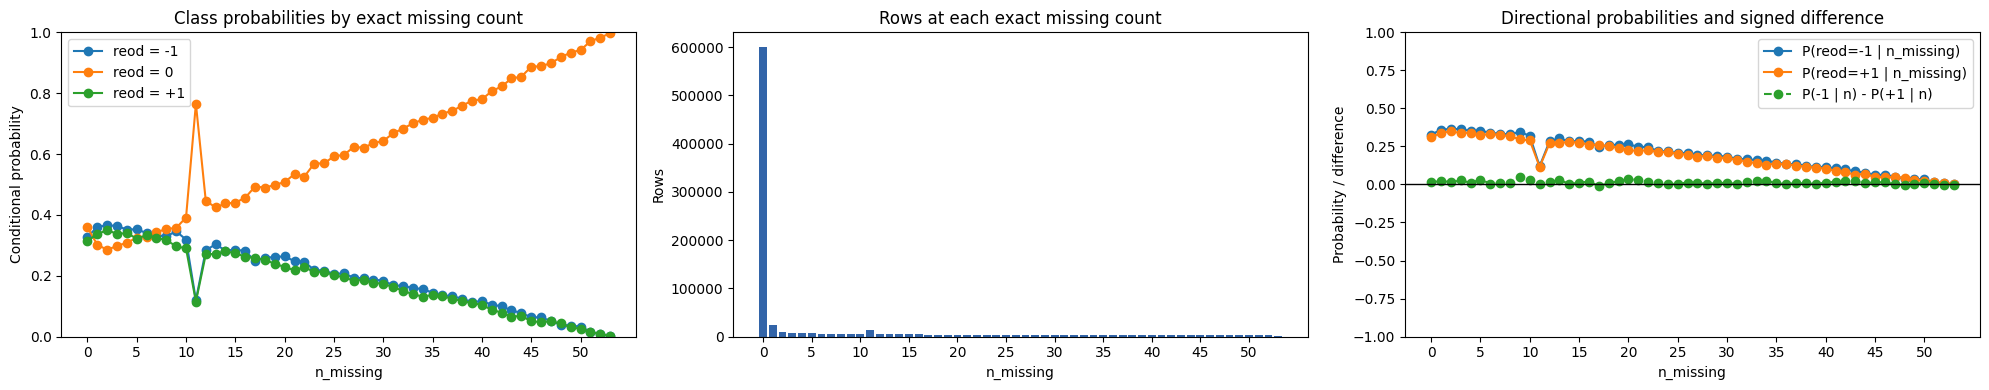

In [15]:
# All plots retain the exact integer x-axis; empty levels remain visible as gaps or zero-height bars.
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

probability_columns = {
    'p_reod_-1_given_n_missing': 'reod = -1',
    'p_reod_0_given_n_missing': 'reod = 0',
    'p_reod_1_given_n_missing': 'reod = +1',
}
for column, label in probability_columns.items():
    axes[0].plot(missing_count_exact_table.index, missing_count_exact_table[column], marker='o', label=label)
axes[0].set(title='Class probabilities by exact missing count', xlabel='n_missing', ylabel='Conditional probability', ylim=(0, 1))
axes[0].set_xticks(range(0, 54, 5))
axes[0].legend()

axes[1].bar(missing_count_exact_table.index, missing_count_exact_table['n_rows'], color='#3264a8')
axes[1].set(title='Rows at each exact missing count', xlabel='n_missing', ylabel='Rows')
axes[1].set_xticks(range(0, 54, 5))

axes[2].plot(missing_count_exact_table.index, missing_count_exact_table['p_reod_-1_given_n_missing'], marker='o', label='P(reod=-1 | n_missing)')
axes[2].plot(missing_count_exact_table.index, missing_count_exact_table['p_reod_1_given_n_missing'], marker='o', label='P(reod=+1 | n_missing)')
axes[2].plot(missing_count_exact_table.index, missing_count_exact_table['p_minus_1_minus_p_plus_1'], marker='o', linestyle='--', label='P(-1 | n) - P(+1 | n)')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set(title='Directional probabilities and signed difference', xlabel='n_missing', ylabel='Probability / difference', ylim=(-1, 1))
axes[2].set_xticks(range(0, 54, 5))
axes[2].legend()

plt.tight_layout()
plt.show()

---

## Exact n_missing=11 mask structure audit

This post-EXP_001 audit uses training data only. Structural summaries are calculated before and separately from any target-conditioned table; structural mask ranking never uses `reod`.

,mask,n_rows,share_of_n11_rows,cumulative_share_of_n11_rows,missing_positions
0,0000000000000000000000000000000000000000001111...,7779,0.610549,0.610549,"r42, r43, r44, r45, r46, r47, r48, r49, r50, r..."
1,0000000000000000000000000000000000000011100110...,1,0.000078,0.610627,"r38, r39, r40, r43, r44, r46, r47, r49, r50, r..."
2,0000000000000000000000000000000000001111001111...,1,0.000078,0.610706,"r36, r37, r38, r39, r42, r43, r44, r45, r47, r..."
3,0000000000000000000000000000000001000010111011...,1,0.000078,0.610784,"r33, r38, r40, r41, r42, r44, r45, r49, r50, r..."
4,0000000000000000000000000000000001100110110110...,1,0.000078,0.610863,"r33, r34, r37, r38, r40, r41, r43, r44, r46, r..."
...,...,...,...,...,...
4958,1111101010010000000000000010100000001000000000...,1,0.000078,0.999686,"r0, r1, r2, r3, r4, r6, r8, r11, r26, r28, r36"
4959,1111101100000000000000100000000000010001000001...,1,0.000078,0.999765,"r0, r1, r2, r3, r4, r6, r7, r22, r35, r39, r45"
4960,1111110000000100100000000000000000001100001000...,1,0.000078,0.999843,"r0, r1, r2, r3, r4, r5, r13, r16, r36, r37, r42"
4961,1111111110000100000001000000000000000000000000...,1,0.000078,0.999922,"r0, r1, r2, r3, r4, r5, r6, r7, r8, r13, r21"


Top 1 structural masks cover: 61.054862%
Top 5 structural masks cover: 61.086257%
Top 10 structural masks cover: 61.125500%


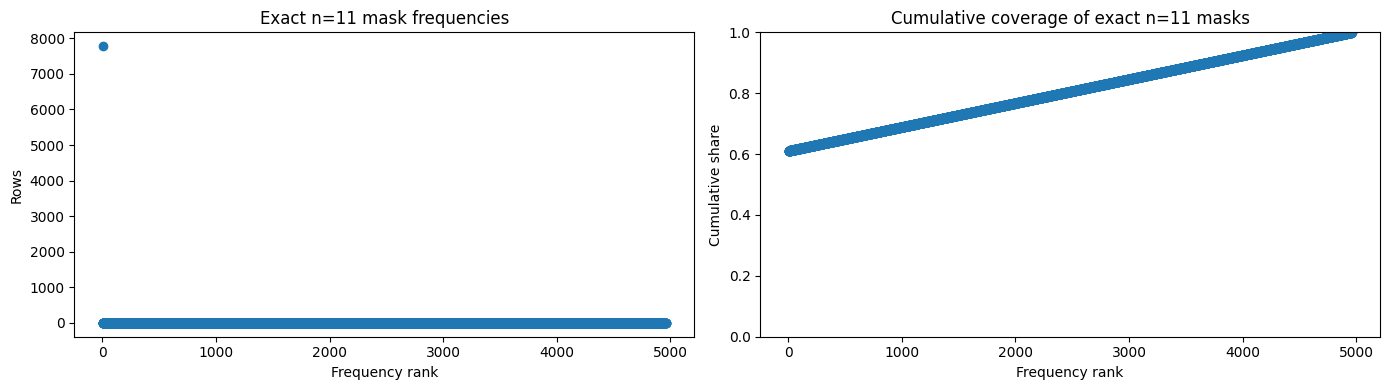

In [16]:
# Structural mask frequency only: 1 denotes an original NaN and the leftmost bit is r0.
n11_rows = n_missing.eq(11)
n11_binary_masks = returns.loc[n11_rows, return_columns].isna().to_numpy(dtype=np.uint8)
n11_mask_keys = pd.Series(
    [''.join(row.astype(str)) for row in n11_binary_masks],
    index=returns.index[n11_rows],
    name='mask',
)
assert len(n11_mask_keys) == 12_741
assert all(mask.count('1') == 11 and len(mask) == 53 for mask in n11_mask_keys.unique())

n11_pattern_structure = (
    n11_mask_keys.value_counts(sort=False)
    .rename_axis('mask').rename('n_rows').reset_index()
    .sort_values(['n_rows', 'mask'], ascending=[False, True], kind='stable')
    .reset_index(drop=True)
)
n11_pattern_structure['share_of_n11_rows'] = n11_pattern_structure['n_rows'] / len(n11_mask_keys)
n11_pattern_structure['cumulative_share_of_n11_rows'] = n11_pattern_structure['share_of_n11_rows'].cumsum()
n11_pattern_structure['missing_positions'] = n11_pattern_structure['mask'].map(
    lambda mask: ', '.join(f'r{position}' for position, bit in enumerate(mask) if bit == '1')
)
assert n11_pattern_structure['n_rows'].sum() == len(n11_mask_keys)
display(n11_pattern_structure)
for top_k in (1, 5, 10):
    print(f'Top {top_k} structural masks cover: {n11_pattern_structure.head(top_k)["share_of_n11_rows"].sum():.6%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rank = np.arange(1, len(n11_pattern_structure) + 1)
axes[0].plot(rank, n11_pattern_structure['n_rows'], marker='o', linestyle='none')
axes[0].set(title='Exact n=11 mask frequencies', xlabel='Frequency rank', ylabel='Rows')
axes[1].plot(rank, n11_pattern_structure['cumulative_share_of_n11_rows'], marker='o')
axes[1].set(title='Cumulative coverage of exact n=11 masks', xlabel='Frequency rank', ylabel='Cumulative share', ylim=(0, 1))
plt.tight_layout()
plt.show()

,n_missing_10,n_missing_11,n_missing_12
return_column,,,
r0,0.143219,0.058080,0.177566
r1,0.268146,0.113884,0.287158
r2,0.282545,0.114512,0.304201
r3,0.228060,0.097245,0.252874
r4,0.216579,0.090103,0.240785
r5,0.217163,0.093399,0.246334
r6,0.194785,0.088141,0.219382
r7,0.164623,0.071423,0.182124
r8,0.183110,0.081312,0.215220


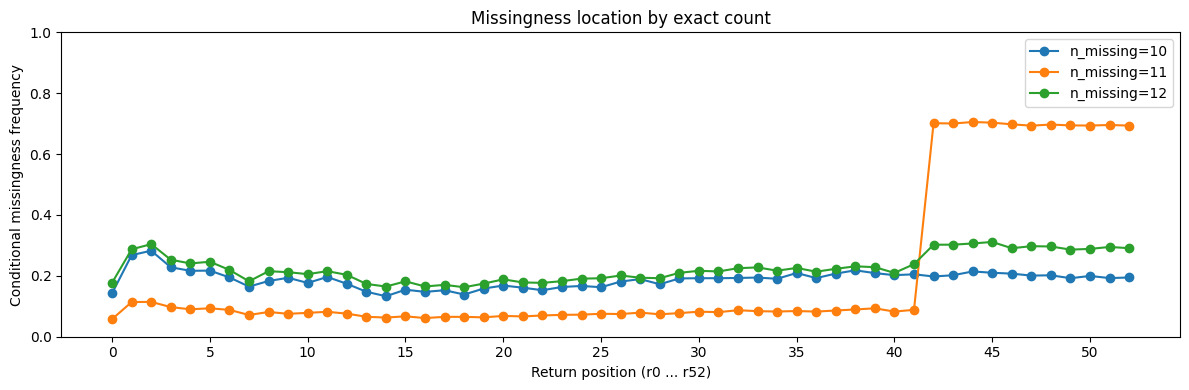

In [17]:
# Structural temporal location comparison only; no target is used in these summaries.
location_levels = (10, 11, 12)
missing_location_by_count = pd.DataFrame({
    f'n_missing_{level}': returns.loc[n_missing.eq(level), return_columns].isna().mean(axis=0)
    for level in location_levels
})
missing_location_by_count.index.name = 'return_column'
assert missing_location_by_count.shape == (53, 3)
display(missing_location_by_count)

fig, ax = plt.subplots(figsize=(12, 4))
for level in location_levels:
    ax.plot(range(53), missing_location_by_count[f'n_missing_{level}'], marker='o', label=f'n_missing={level}')
ax.set(title='Missingness location by exact count', xlabel='Return position (r0 ... r52)', ylabel='Conditional missingness frequency', ylim=(0, 1))
ax.set_xticks(range(0, 53, 5))
ax.legend()
plt.tight_layout()
plt.show()

,n_rows
longest_run_length,
1,165
2,2397
3,1600
4,565
5,161
6,45
7,12
8,13
9,3


,n_rows
n_missing_runs,
1,7780
2,2
3,13
4,37
5,144
6,442
7,847
8,1333
9,1290


n_rows
principal_run_start principal_run_end        
42                  52                   7779
1                   3                     108
                    4                      73
50                  52                     54
44                  46                     44
...                                       ...
40                  45                      1
45                  50                      1
                    52                      1
44                  49                      1
47                  51                      1

[242 rows x 1 columns]

Rows with tied longest runs: 2100


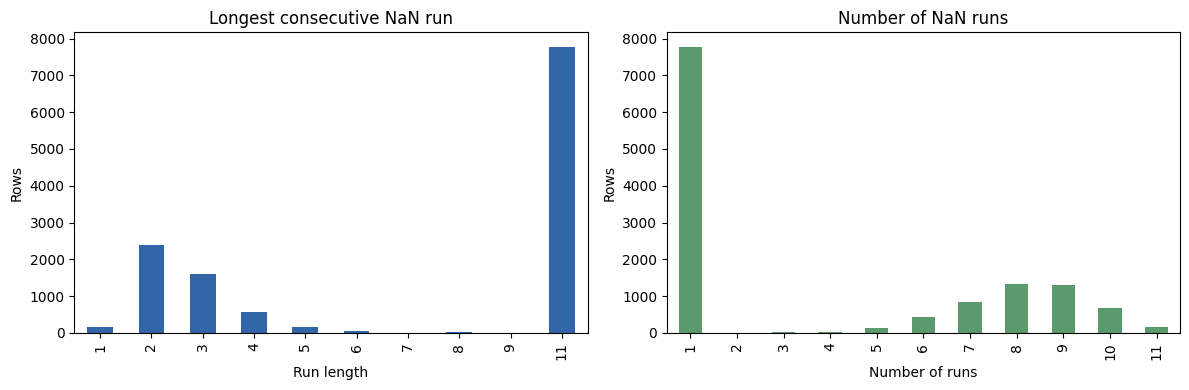

In [18]:
# Consecutive-run structure only. Tied longest runs retain no arbitrary principal location.
def summarize_missing_runs(mask_row):
    runs, run_start = [], None
    for position, is_missing in enumerate(mask_row):
        if is_missing and run_start is None:
            run_start = position
        elif not is_missing and run_start is not None:
            runs.append((run_start, position - 1))
            run_start = None
    if run_start is not None:
        runs.append((run_start, len(mask_row) - 1))
    lengths = [end - start + 1 for start, end in runs]
    longest_length = max(lengths)
    longest_runs = [run for run, length in zip(runs, lengths) if length == longest_length]
    record = {
        'longest_run_length': longest_length,
        'n_missing_runs': len(runs),
        'n_tied_longest_runs': len(longest_runs),
        'principal_run_is_unique': len(longest_runs) == 1,
        'principal_run_start': pd.NA,
        'principal_run_end': pd.NA,
    }
    if len(longest_runs) == 1:
        record['principal_run_start'], record['principal_run_end'] = longest_runs[0]
    return record

n11_run_structure = pd.DataFrame([summarize_missing_runs(row.astype(bool)) for row in n11_binary_masks])
assert len(n11_run_structure) == len(n11_mask_keys)
assert (n11_run_structure['longest_run_length'] <= 11).all()

n11_longest_run_distribution = n11_run_structure['longest_run_length'].value_counts().sort_index().rename('n_rows').to_frame()
n11_number_of_runs_distribution = n11_run_structure['n_missing_runs'].value_counts().sort_index().rename('n_rows').to_frame()
n11_unique_principal_runs = (
    n11_run_structure.loc[n11_run_structure['principal_run_is_unique']]
    .groupby(['principal_run_start', 'principal_run_end']).size().rename('n_rows')
    .sort_values(ascending=False).to_frame()
)
display(n11_longest_run_distribution)
display(n11_number_of_runs_distribution)
display(n11_unique_principal_runs)
print('Rows with tied longest runs:', int((~n11_run_structure['principal_run_is_unique']).sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n11_longest_run_distribution.plot.bar(ax=axes[0], legend=False, color='#3264a8')
axes[0].set(title='Longest consecutive NaN run', xlabel='Run length', ylabel='Rows')
n11_number_of_runs_distribution.plot.bar(ax=axes[1], legend=False, color='#5b9a6d')
axes[1].set(title='Number of NaN runs', xlabel='Number of runs', ylabel='Rows')
plt.tight_layout()
plt.show()

### Target-conditioned composition by exact mask

The next table joins `reod` only after the structural ranking above has been fixed. It reports every observed mask; no mask is filtered or selected using its target composition.

,n_rows,share_of_n11_rows,cumulative_share_of_n11_rows,missing_positions,count_reod_-1,p_reod_-1_given_mask,count_reod_0,p_reod_0_given_mask,count_reod_1,p_reod_1_given_mask
mask,,,,,,,,,,
00000000000000000000000000000000000000000011111111111,7779,0.610549,0.610549,"r42, r43, r44, r45, r46, r47, r48, r49, r50, r...",0,0.0,7779,1.0,0,0.0
00000000000000000000000000000000000000111001101101111,1,0.000078,0.610627,"r38, r39, r40, r43, r44, r46, r47, r49, r50, r...",0,0.0,1,1.0,0,0.0
00000000000000000000000000000000000011110011110100011,1,0.000078,0.610706,"r36, r37, r38, r39, r42, r43, r44, r45, r47, r...",0,0.0,0,0.0,1,1.0
00000000000000000000000000000000010000101110110001111,1,0.000078,0.610784,"r33, r38, r40, r41, r42, r44, r45, r49, r50, r...",0,0.0,1,1.0,0,0.0
00000000000000000000000000000000011001101101101100001,1,0.000078,0.610863,"r33, r34, r37, r38, r40, r41, r43, r44, r46, r...",0,0.0,1,1.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...
11111010100100000000000000101000000010000000000000000,1,0.000078,0.999686,"r0, r1, r2, r3, r4, r6, r8, r11, r26, r28, r36",0,0.0,1,1.0,0,0.0
11111011000000000000001000000000000100010000010000000,1,0.000078,0.999765,"r0, r1, r2, r3, r4, r6, r7, r22, r35, r39, r45",1,1.0,0,0.0,0,0.0
11111100000001001000000000000000000011000010000000000,1,0.000078,0.999843,"r0, r1, r2, r3, r4, r5, r13, r16, r36, r37, r42",0,0.0,0,0.0,1,1.0


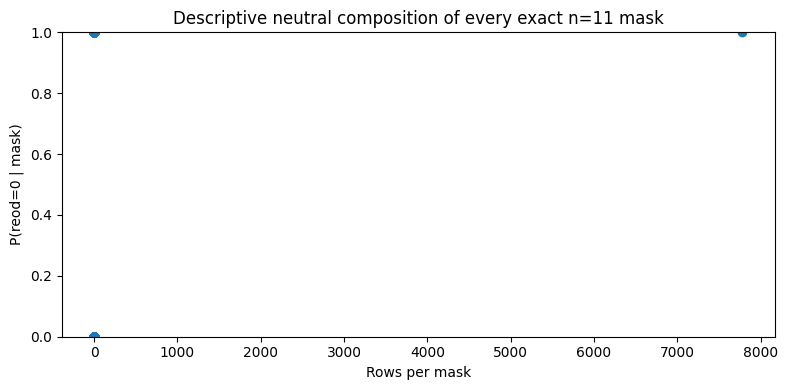

Interpretation boundary: this is a pooled descriptive target association. The scatter is not used to select masks or define a threshold.


In [19]:
# Target composition is reported for every structurally observed mask, in the pre-existing structural order.
n11_pattern_target_counts = (
    pd.crosstab(n11_mask_keys, y_train.loc[n11_rows])
    .reindex(index=n11_pattern_structure['mask'], columns=classes, fill_value=0)
)
n11_pattern_target_table = n11_pattern_structure.set_index('mask').copy()
for label in classes:
    n11_pattern_target_table[f'count_reod_{label}'] = n11_pattern_target_counts[label]
    n11_pattern_target_table[f'p_reod_{label}_given_mask'] = n11_pattern_target_counts[label] / n11_pattern_target_table['n_rows']
assert (n11_pattern_target_table[[f'count_reod_{label}' for label in classes]].sum(axis=1) == n11_pattern_target_table['n_rows']).all()
assert np.allclose(n11_pattern_target_table[[f'p_reod_{label}_given_mask' for label in classes]].sum(axis=1), 1.0)
display(n11_pattern_target_table)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(n11_pattern_target_table['n_rows'], n11_pattern_target_table['p_reod_0_given_mask'])
ax.set(title='Descriptive neutral composition of every exact n=11 mask', xlabel='Rows per mask', ylabel='P(reod=0 | mask)', ylim=(0, 1))
plt.tight_layout()
plt.show()
print('Interpretation boundary: this is a pooled descriptive target association. The scatter is not used to select masks or define a threshold.')

---

## Dominant r42...r52 missing-mask structure across day and equity

This section is structural only: it uses the mask, `day`, and `equity`, never `reod`. Consecutive sessions mean exactly adjacent `day` identifiers, `t` and `t+1`; this does not assert calendar-day distance.

In [20]:
# Identify the structurally dominant n_missing=11 pattern without consulting the target.
dominant_mask = n11_pattern_structure.loc[0, 'mask']
assert dominant_mask == ('0' * 42 + '1' * 11)
dominant_mask_indices = n11_mask_keys.index[n11_mask_keys.eq(dominant_mask)]
dominant_mask_frame = X_train.loc[dominant_mask_indices, ['ID', 'day', 'equity']].copy()
assert len(dominant_mask_frame) == 7_779
assert not dominant_mask_frame[['day', 'equity']].duplicated().any()
assert X_train.loc[dominant_mask_indices, return_columns[:42]].notna().all().all()
assert X_train.loc[dominant_mask_indices, return_columns[42:]].isna().all().all()
print('Dominant-mask rows:', len(dominant_mask_frame))
print('Dominant-mask missing positions:', ', '.join(return_columns[42:]))

Dominant-mask rows: 7779
Dominant-mask missing positions: r42, r43, r44, r45, r46, r47, r48, r49, r50, r51, r52


,n_rows,share_of_dominant_rows
day,,
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
...,...,...
498,0,0.0
499,0,0.0
500,0,0.0


,n_rows,share_of_dominant_rows
day,,
112,1245,0.160046
134,1207,0.155161
229,1176,0.151176
314,1243,0.159789
438,1487,0.191156
469,1421,0.182671


,n_rows
count,6.000000
mean,1296.500000
std,126.360991
min,1176.000000
1%,1177.550000
10%,1191.500000
25%,1216.000000
50%,1244.000000
75%,1377.000000
90%,1454.000000


Affected day IDs: 6 of 503 (1.192843%)


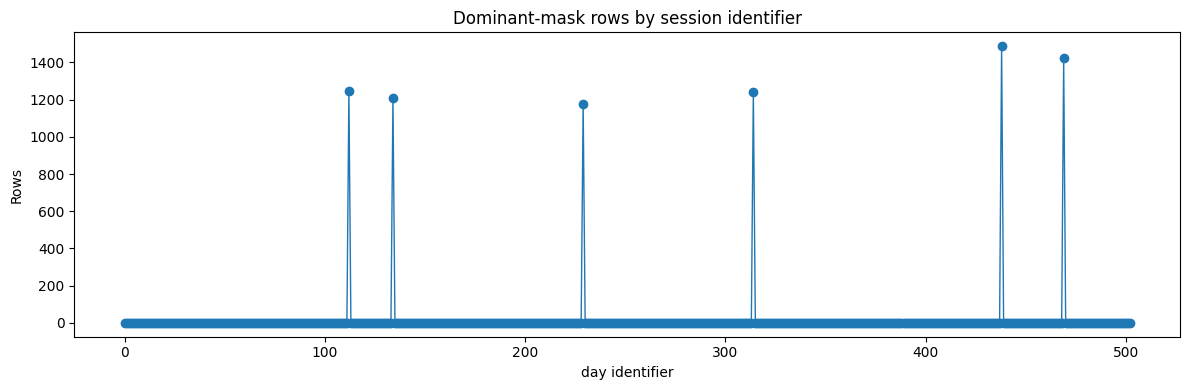

In [21]:
# Temporal distribution across all chronological session identifiers; no target columns are used.
dominant_by_day = (
    dominant_mask_frame.groupby('day').size().reindex(range(503), fill_value=0).rename('n_rows').to_frame()
)
dominant_by_day['share_of_dominant_rows'] = dominant_by_day['n_rows'] / len(dominant_mask_frame)
dominant_day_affected = dominant_by_day['n_rows'] > 0
assert dominant_by_day['n_rows'].sum() == len(dominant_mask_frame)
display(dominant_by_day)
display(dominant_by_day.loc[dominant_day_affected])
display(dominant_by_day.loc[dominant_day_affected, 'n_rows'].describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).to_frame())
print(f'Affected day IDs: {int(dominant_day_affected.sum())} of 503 ({dominant_day_affected.mean():.6%})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dominant_by_day.index, dominant_by_day['n_rows'], marker='o', linewidth=1)
ax.set(title='Dominant-mask rows by session identifier', xlabel='day identifier', ylabel='Rows')
plt.tight_layout()
plt.show()

,equity,n_rows,share_of_dominant_rows,cumulative_share_of_dominant_rows
0,0,6,0.000771,0.000771
1,2,6,0.000771,0.001543
2,3,6,0.000771,0.002314
3,8,6,0.000771,0.003085
4,10,6,0.000771,0.003857
...,...,...,...,...
1637,1770,1,0.000129,0.999486
1638,1799,1,0.000129,0.999614
1639,1812,1,0.000129,0.999743
1640,1825,1,0.000129,0.999871


,n_rows
count,1642.000000
mean,4.737515
std,1.759430
min,1.000000
1%,1.000000
10%,2.000000
25%,3.000000
50%,6.000000
75%,6.000000
90%,6.000000


Top 1 equities cover: 0.077131%
Top 5 equities cover: 0.385654%
Top 10 equities cover: 0.771307%
Top 50 equities cover: 3.856537%


Affected equities: 1642 of 1829 (89.775834%)


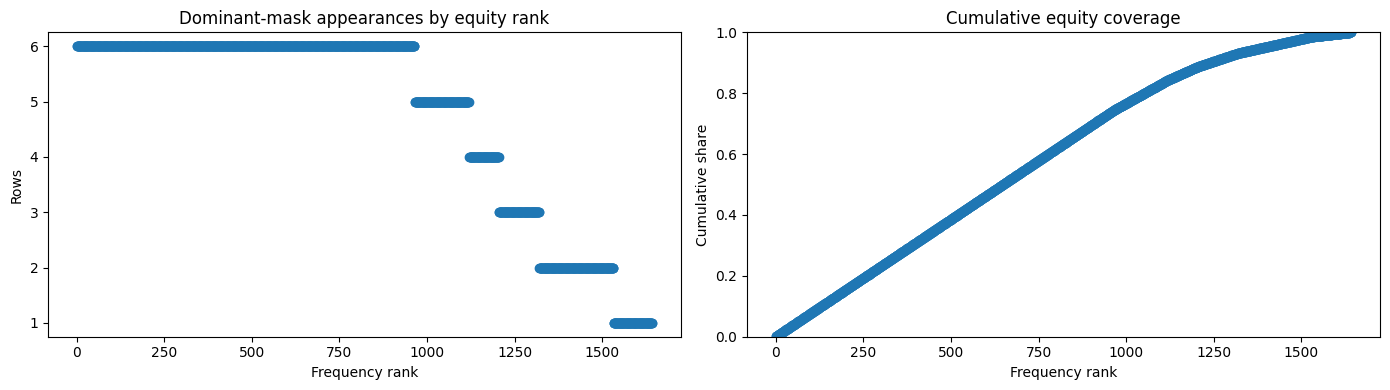

In [22]:
# Cross-sectional concentration, ranked only by structural mask frequency.
dominant_by_equity = (
    dominant_mask_frame.groupby('equity').size().rename('n_rows').reset_index()
    .sort_values(['n_rows', 'equity'], ascending=[False, True], kind='stable').reset_index(drop=True)
)
dominant_by_equity['share_of_dominant_rows'] = dominant_by_equity['n_rows'] / len(dominant_mask_frame)
dominant_by_equity['cumulative_share_of_dominant_rows'] = dominant_by_equity['share_of_dominant_rows'].cumsum()
assert dominant_by_equity['n_rows'].sum() == len(dominant_mask_frame)
display(dominant_by_equity)
display(dominant_by_equity['n_rows'].describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).to_frame())
for top_k in (1, 5, 10, 50):
    print(f'Top {top_k} equities cover: {dominant_by_equity.head(top_k)["share_of_dominant_rows"].sum():.6%}')
print(f'Affected equities: {len(dominant_by_equity)} of {X_train["equity"].nunique()} ({len(dominant_by_equity) / X_train["equity"].nunique():.6%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
equity_rank = np.arange(1, len(dominant_by_equity) + 1)
axes[0].plot(equity_rank, dominant_by_equity['n_rows'], marker='o', linestyle='none')
axes[0].set(title='Dominant-mask appearances by equity rank', xlabel='Frequency rank', ylabel='Rows')
axes[1].plot(equity_rank, dominant_by_equity['cumulative_share_of_dominant_rows'], marker='o')
axes[1].set(title='Cumulative equity coverage', xlabel='Frequency rank', ylabel='Cumulative share', ylim=(0, 1))
plt.tight_layout()
plt.show()

,equity,n_mask_appearances,n_session_blocks,max_session_block_length,first_mask_day,last_mask_day,last_observed_day,n_observed_sessions_from_first_mask,n_mask_sessions_from_first_mask,n_normal_observed_sessions_after_first_mask,first_normal_observed_day_after_mask,first_normal_day_identifier_gap_after_mask,n_mask_sessions_after_first_normal,mask_reappears_after_normal_observation,n_nonadjacent_day_identifier_steps_from_first_mask,persistence_complete_to_last_observed_day,appearance_type
0,0,6,6,1,112,469,502,391,6,385,113,1,5,True,0,False,multiple_session_blocks
1,2,6,6,1,112,469,502,391,6,385,113,1,5,True,0,False,multiple_session_blocks
2,3,6,6,1,112,469,502,391,6,385,113,1,5,True,0,False,multiple_session_blocks
3,4,2,2,1,438,469,502,50,2,48,439,1,1,True,10,False,multiple_session_blocks
4,5,2,2,1,438,469,502,65,2,63,439,1,1,True,0,False,multiple_session_blocks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,1824,6,6,1,112,469,502,347,6,341,113,1,5,True,39,False,multiple_session_blocks
1638,1825,1,1,1,112,112,499,119,1,118,114,2,0,False,78,False,single_appearance
1639,1826,6,6,1,112,469,502,391,6,385,113,1,5,True,0,False,multiple_session_blocks
1640,1827,6,6,1,112,469,502,391,6,385,113,1,5,True,0,False,multiple_session_blocks


,n_equities,share_of_affected_equities
appearance_type,,
single_appearance,111,0.0676
single_session_block,0,0.0000
multiple_session_blocks,1531,0.9324


,n_equities,share_of_affected_equities
n_mask_appearances,,
1,111,0.067600
2,212,0.129111
3,115,0.070037
4,85,0.051766
5,155,0.094397
6,964,0.587089


,n_mask_appearances
count,1642.000000
mean,4.737515
std,1.759430
min,1.000000
1%,1.000000
10%,2.000000
25%,3.000000
50%,6.000000
75%,6.000000
90%,6.000000


,value
n_affected_equities,1642.0
n_complete_persistence,0.0
share_complete_persistence,0.0
n_nonpersistent,1642.0
n_nonpersistent_with_mask_reappearing_after_normal,1531.0
n_nonpersistent_without_mask_reappearing_after_normal,111.0


,n_mask_appearances,n_session_blocks,max_session_block_length,first_mask_day,last_mask_day,last_observed_day,n_observed_sessions_from_first_mask,n_mask_sessions_from_first_mask,n_normal_observed_sessions_after_first_mask,first_normal_observed_day_after_mask,first_normal_day_identifier_gap_after_mask,n_mask_sessions_after_first_normal,n_nonadjacent_day_identifier_steps_from_first_mask
count,1642.000000,1642.000000,1642.0,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000,1642.000000
mean,4.737515,4.737515,1.0,168.448843,448.099269,501.809379,320.440317,4.737515,315.702801,169.592570,1.143727,3.737515,6.839220
std,1.759430,1.759430,0.0,116.411053,68.738360,2.245903,124.140228,1.759430,122.596083,116.552526,1.341250,1.759430,21.291362
min,1.000000,1.000000,1.0,112.000000,112.000000,423.000000,4.000000,1.000000,3.000000,113.000000,1.000000,0.000000,0.000000
1%,1.000000,1.000000,1.0,112.000000,112.000000,498.000000,23.640000,1.000000,22.050000,113.000000,1.000000,0.000000,0.000000
10%,2.000000,2.000000,1.0,112.000000,438.000000,502.000000,65.000000,2.000000,63.000000,113.000000,1.000000,1.000000,0.000000
25%,3.000000,3.000000,1.0,112.000000,469.000000,502.000000,283.250000,3.000000,278.750000,113.000000,1.000000,2.000000,0.000000
50%,6.000000,6.000000,1.0,112.000000,469.000000,502.000000,391.000000,6.000000,385.000000,113.000000,1.000000,5.000000,0.000000
75%,6.000000,6.000000,1.0,112.000000,469.000000,502.000000,391.000000,6.000000,385.000000,114.000000,1.000000,5.000000,0.000000
90%,6.000000,6.000000,1.0,438.000000,469.000000,502.000000,391.000000,6.000000,386.000000,439.000000,1.000000,5.000000,11.000000


First normal observation has adjacent day identifier after first mask: 1557


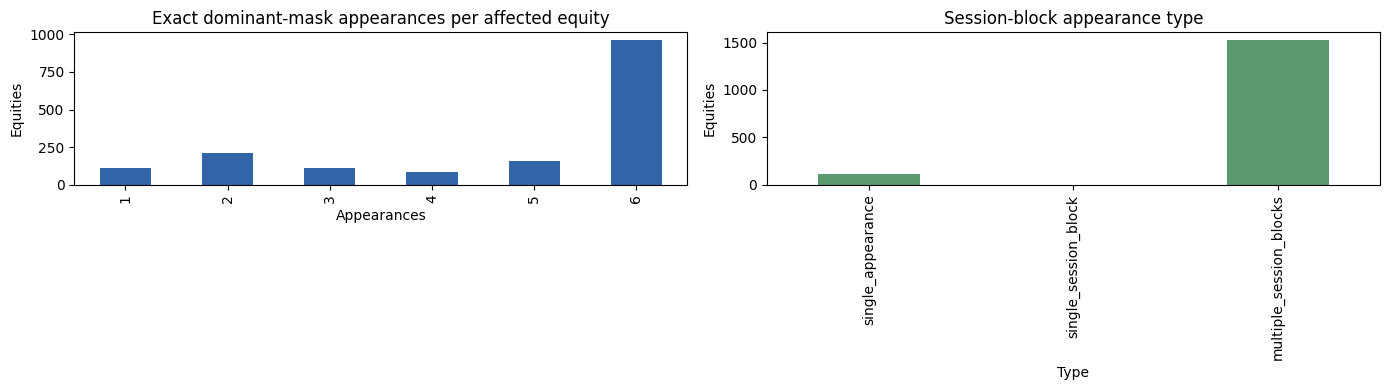

Interpretation boundary: session adjacency uses day=t and day=t+1 only; it is not interpreted as calendar-day spacing.


In [23]:
# Within-equity session blocks and persistence use only day/equity/mask information.
def session_blocks(day_values):
    ordered_days = np.sort(np.asarray(day_values, dtype=int))
    starts = np.r_[0, np.flatnonzero(np.diff(ordered_days) != 1) + 1]
    ends = np.r_[starts[1:] - 1, len(ordered_days) - 1]
    return [(int(ordered_days[start]), int(ordered_days[end])) for start, end in zip(starts, ends)]

equity_structure_records = []
for equity, group in dominant_mask_frame.groupby('equity', sort=True):
    mask_days = np.sort(group['day'].unique())
    observed_days = np.sort(X_train.loc[X_train['equity'].eq(equity), 'day'].unique())
    blocks = session_blocks(mask_days)
    first_mask_day = int(mask_days[0])
    last_observed_day = int(observed_days[-1])
    observed_tail_days = observed_days[observed_days >= first_mask_day]
    mask_day_set = set(mask_days)
    normal_tail_days = np.asarray([day for day in observed_tail_days if day not in mask_day_set], dtype=int)
    first_normal_after_mask = int(normal_tail_days[0]) if len(normal_tail_days) else pd.NA
    n_mask_after_first_normal = (mask_days > first_normal_after_mask).sum() if len(normal_tail_days) else 0
    first_normal_day_identifier_gap = first_normal_after_mask - first_mask_day if len(normal_tail_days) else pd.NA
    n_nonadjacent_day_identifier_steps_in_tail = int(np.sum(np.diff(observed_tail_days) != 1))
    if len(mask_days) == 1:
        appearance_type = 'single_appearance'
    elif len(blocks) == 1:
        appearance_type = 'single_session_block'
    else:
        appearance_type = 'multiple_session_blocks'
    equity_structure_records.append({
        'equity': equity,
        'n_mask_appearances': len(mask_days),
        'n_session_blocks': len(blocks),
        'max_session_block_length': max(end - start + 1 for start, end in blocks),
        'first_mask_day': first_mask_day,
        'last_mask_day': int(mask_days[-1]),
        'last_observed_day': last_observed_day,
        'n_observed_sessions_from_first_mask': len(observed_tail_days),
        'n_mask_sessions_from_first_mask': len(mask_days),
        'n_normal_observed_sessions_after_first_mask': len(normal_tail_days),
        'first_normal_observed_day_after_mask': first_normal_after_mask,
        'first_normal_day_identifier_gap_after_mask': first_normal_day_identifier_gap,
        'n_mask_sessions_after_first_normal': int(n_mask_after_first_normal),
        'mask_reappears_after_normal_observation': bool(n_mask_after_first_normal > 0),
        'n_nonadjacent_day_identifier_steps_from_first_mask': n_nonadjacent_day_identifier_steps_in_tail,
        'persistence_complete_to_last_observed_day': len(normal_tail_days) == 0,
        'appearance_type': appearance_type,
    })

dominant_equity_structure = pd.DataFrame(equity_structure_records).sort_values('equity').reset_index(drop=True)
assert len(dominant_equity_structure) == len(dominant_by_equity)
assert dominant_equity_structure['n_mask_appearances'].sum() == len(dominant_mask_frame)
display(dominant_equity_structure)

appearance_distribution = dominant_equity_structure['appearance_type'].value_counts().reindex(
    ['single_appearance', 'single_session_block', 'multiple_session_blocks'], fill_value=0
).rename('n_equities').to_frame()
appearance_distribution['share_of_affected_equities'] = appearance_distribution['n_equities'] / len(dominant_equity_structure)
display(appearance_distribution)
appearance_count_distribution = dominant_equity_structure['n_mask_appearances'].value_counts().sort_index().rename('n_equities').to_frame()
appearance_count_distribution['share_of_affected_equities'] = appearance_count_distribution['n_equities'] / len(dominant_equity_structure)
display(appearance_count_distribution)
display(dominant_equity_structure['n_mask_appearances'].describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).to_frame())

persistence_summary = pd.Series({
    'n_affected_equities': len(dominant_equity_structure),
    'n_complete_persistence': int(dominant_equity_structure['persistence_complete_to_last_observed_day'].sum()),
    'share_complete_persistence': float(dominant_equity_structure['persistence_complete_to_last_observed_day'].mean()),
    'n_nonpersistent': int((~dominant_equity_structure['persistence_complete_to_last_observed_day']).sum()),
    'n_nonpersistent_with_mask_reappearing_after_normal': int((~dominant_equity_structure['persistence_complete_to_last_observed_day'] & dominant_equity_structure['mask_reappears_after_normal_observation']).sum()),
    'n_nonpersistent_without_mask_reappearing_after_normal': int((~dominant_equity_structure['persistence_complete_to_last_observed_day'] & ~dominant_equity_structure['mask_reappears_after_normal_observation']).sum()),
}, name='value').to_frame()
display(persistence_summary)
nonpersistent_equity_structure = dominant_equity_structure.loc[~dominant_equity_structure['persistence_complete_to_last_observed_day']].copy()
display(nonpersistent_equity_structure.drop(columns='equity').describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]))
print('First normal observation has adjacent day identifier after first mask:', int((nonpersistent_equity_structure['first_normal_day_identifier_gap_after_mask'] == 1).sum()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dominant_equity_structure['n_mask_appearances'].value_counts().sort_index().plot.bar(ax=axes[0], color='#3264a8')
axes[0].set(title='Exact dominant-mask appearances per affected equity', xlabel='Appearances', ylabel='Equities')
appearance_distribution['n_equities'].plot.bar(ax=axes[1], color='#5b9a6d')
axes[1].set(title='Session-block appearance type', xlabel='Type', ylabel='Equities')
plt.tight_layout()
plt.show()
print('Interpretation boundary: session adjacency uses day=t and day=t+1 only; it is not interpreted as calendar-day spacing.')

---

## Session-level cross-sectional missingness structure

This audit uses only training `day`, `equity`, and `returns.isna()`. It does not use `reod`. The mask-concentration index is interpreted jointly with session missingness intensity and the modal-mask identity, because a concentrated fully observed mask is not shared missingness.

return_column,r0,r1,r2,r3,r4,r5,r6,r7,r8,r9,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
day,,,,,,,,,,,,,,,,,,,,,
0,0.052319,0.119501,0.102854,0.123068,0.092152,0.124851,0.113555,0.096908,0.116528,0.127824,...,0.083234,0.096908,0.102854,0.114744,0.107610,0.057669,0.087990,0.098692,0.112366,0.101665
1,0.048329,0.119928,0.158711,0.146181,0.142601,0.145585,0.113962,0.122315,0.086516,0.131862,...,0.118735,0.113365,0.093675,0.087709,0.108592,0.112768,0.115155,0.115752,0.102029,0.109785
2,0.069007,0.118977,0.132659,0.129685,0.109459,0.119572,0.114813,0.107674,0.115407,0.106484,...,0.101725,0.121951,0.112433,0.113028,0.119572,0.110054,0.120761,0.133254,0.102915,0.104105
3,0.041194,0.133731,0.119403,0.139701,0.129552,0.142090,0.131343,0.124776,0.132537,0.115821,...,0.117015,0.117015,0.125373,0.107463,0.093731,0.117612,0.124179,0.117612,0.131343,0.114627
4,0.051449,0.120639,0.136606,0.121821,0.105263,0.118273,0.094027,0.120639,0.111177,0.108220,...,0.094027,0.106446,0.092253,0.096984,0.104672,0.098167,0.099349,0.088114,0.095801,0.095801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,0.045481,0.116361,0.135263,0.119905,0.132310,0.130538,0.105729,0.113408,0.112227,0.122859,...,0.117543,0.118724,0.116952,0.107501,0.118724,0.116361,0.104548,0.103957,0.116361,0.116361
499,0.056261,0.099214,0.099214,0.107683,0.093164,0.086509,0.108893,0.107683,0.115547,0.117362,...,0.113128,0.107078,0.101633,0.114943,0.122202,0.113733,0.107683,0.127042,0.114943,0.102843
500,0.065205,0.119739,0.112626,0.128631,0.119146,0.113811,0.109662,0.102549,0.107884,0.111440,...,0.110255,0.082988,0.106106,0.104327,0.101956,0.110255,0.091286,0.101956,0.109069,0.107291


,mean_q_tj,max_q_tj,max_q_position
day,,,
0,0.099029,0.127824,r9
1,0.110078,0.158711,r2
2,0.109560,0.133254,r50
3,0.116508,0.142090,r5
4,0.098948,0.136606,r2
...,...,...,...
498,0.112996,0.135263,r2
499,0.100891,0.127042,r50
500,0.103477,0.128631,r3


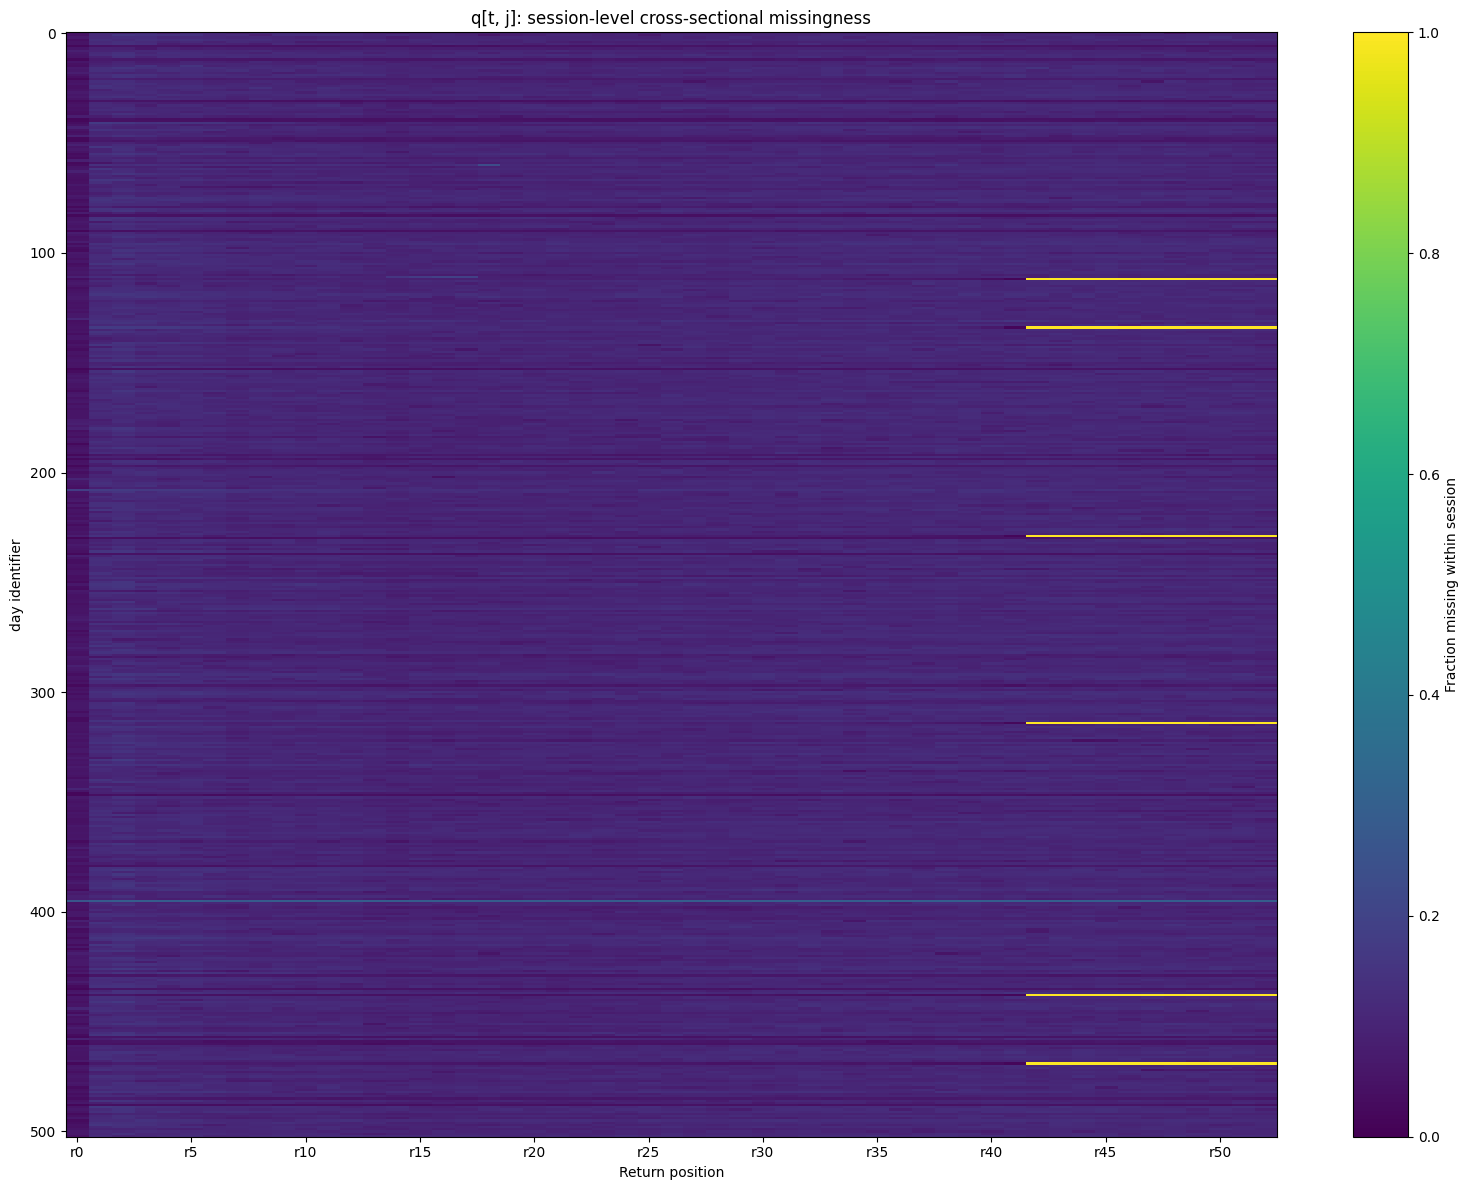

In [24]:
# q[t, j]: fraction of observed equities in each session with NaN at return position j.
session_position_missingness = returns.isna().groupby(X_train['day']).mean().reindex(index=range(503), columns=return_columns)
session_position_missingness.index.name = 'day'
assert session_position_missingness.shape == (503, 53)
assert session_position_missingness.ge(0).all().all() and session_position_missingness.le(1).all().all()

session_q_summary = pd.DataFrame({
    'mean_q_tj': session_position_missingness.mean(axis=1),
    'max_q_tj': session_position_missingness.max(axis=1),
    'max_q_position': session_position_missingness.idxmax(axis=1),
})
display(session_position_missingness)
display(session_q_summary)

fig, ax = plt.subplots(figsize=(16, 12))
image = ax.imshow(session_position_missingness.to_numpy(), aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='viridis')
ax.set(title='q[t, j]: session-level cross-sectional missingness', xlabel='Return position', ylabel='day identifier')
ax.set_xticks(range(0, 53, 5))
ax.set_xticklabels([f'r{position}' for position in range(0, 53, 5)])
fig.colorbar(image, ax=ax, label='Fraction missing within session')
plt.tight_layout()
plt.show()

In [25]:
# Exact 53-bit mask counts by session. Bytes retain exact binary identity without using the target.
all_missing_mask = returns.isna().to_numpy(dtype=np.uint8)
packed_missing_mask = np.packbits(all_missing_mask, axis=1, bitorder='big')
session_mask_frame = pd.DataFrame({
    'day': X_train['day'].to_numpy(),
    'mask_key': [bytes(row) for row in packed_missing_mask],
})
assert all_missing_mask.shape == (len(X_train), 53)
assert session_mask_frame['day'].isin(range(503)).all()

def unpack_mask_key(mask_key):
    return ''.join(np.unpackbits(np.frombuffer(mask_key, dtype=np.uint8), bitorder='big')[:53].astype(str))

session_mask_counts = session_mask_frame.groupby(['day', 'mask_key'], sort=True).size().rename('n_rows').reset_index()
assert session_mask_counts.groupby('day')['n_rows'].sum().reindex(range(503)).equals(X_train.groupby('day').size().reindex(range(503)))

session_mask_records = []
for day, group in session_mask_counts.groupby('day', sort=True):
    counts = group['n_rows'].to_numpy(dtype=int)
    n_rows = int(counts.sum())
    modal_n_rows = int(counts.max())
    modal_keys = sorted(group.loc[group['n_rows'].eq(modal_n_rows), 'mask_key'])
    modal_mask = unpack_mask_key(modal_keys[0])
    ordered_counts = np.sort(counts)[::-1]
    shares = ordered_counts / n_rows
    concentration_h = float(np.square(shares).sum())
    session_mask_records.append({
        'day': int(day),
        'n_rows': n_rows,
        'n_distinct_masks': int(len(group)),
        'modal_mask': modal_mask,
        'modal_mask_has_missingness': '1' in modal_mask,
        'n_modal_tied_masks': int(len(modal_keys)),
        'modal_n_rows': modal_n_rows,
        'modal_mask_share': modal_n_rows / n_rows,
        'top_1_coverage': float(shares[:1].sum()),
        'top_5_coverage': float(shares[:5].sum()),
        'top_10_coverage': float(shares[:10].sum()),
        'mask_concentration_h': concentration_h,
        'effective_n_masks': 1.0 / concentration_h,
    })

session_mask_summary = pd.DataFrame(session_mask_records).set_index('day').reindex(range(503))
assert len(session_mask_summary) == 503
assert (session_mask_summary['top_1_coverage'] <= session_mask_summary['top_5_coverage']).all()
assert (session_mask_summary['top_5_coverage'] <= session_mask_summary['top_10_coverage']).all()
assert session_mask_summary['top_10_coverage'].le(1).all()
assert (session_mask_summary['mask_concentration_h'] >= 1 / session_mask_summary['n_distinct_masks']).all()
assert session_mask_summary['mask_concentration_h'].le(1).all()
display(session_mask_summary)
display(session_mask_summary.drop(columns='modal_mask').describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]))

,n_rows,n_distinct_masks,modal_mask,modal_mask_has_missingness,n_modal_tied_masks,modal_n_rows,modal_mask_share,top_1_coverage,top_5_coverage,top_10_coverage,mask_concentration_h,effective_n_masks
day,,,,,,,,,,,,
0,1682,444,0000000000000000000000000000000000000000000000...,False,1,1213,0.721165,0.721165,0.739001,0.741974,0.520378,1.921680
1,1676,443,0000000000000000000000000000000000000000000000...,False,1,1189,0.709427,0.709427,0.734487,0.741050,0.503739,1.985153
2,1681,440,0000000000000000000000000000000000000000000000...,False,1,1191,0.708507,0.708507,0.738846,0.744200,0.502803,1.988851
3,1675,449,0000000000000000000000000000000000000000000000...,False,1,1188,0.709254,0.709254,0.731940,0.737910,0.503410,1.986453
4,1691,445,0000000000000000000000000000000000000000000000...,False,1,1202,0.710822,0.710822,0.736251,0.742164,0.505801,1.977064
...,...,...,...,...,...,...,...,...,...,...,...,...
498,1693,470,0000000000000000000000000000000000000000000000...,False,1,1189,0.702304,0.702304,0.722977,0.728293,0.493644,2.025751
499,1653,427,0000000000000000000000000000000000000000000000...,False,1,1197,0.724138,0.724138,0.744102,0.747731,0.524741,1.905702
500,1687,422,0000000000000000000000000000000000000000000000...,False,1,1207,0.715471,0.715471,0.750445,0.755779,0.512685,1.950514


,n_rows,n_distinct_masks,n_modal_tied_masks,modal_n_rows,modal_mask_share,top_1_coverage,top_5_coverage,top_10_coverage,mask_concentration_h,effective_n_masks
count,503.000000,503.000000,503.0,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,1676.538767,427.862823,1.0,1210.168986,0.721752,0.721752,0.745295,0.750380,0.522765,1.928150
std,16.061076,50.268592,0.0,61.552890,0.034072,0.034072,0.030870,0.030422,0.051886,0.158171
min,1633.000000,91.000000,1.0,952.000000,0.562980,0.562980,0.671200,0.709048,0.320920,1.316003
1%,1634.000000,214.020000,1.0,1131.040000,0.679027,0.679027,0.717196,0.724201,0.462785,1.328881
10%,1648.000000,413.000000,1.0,1177.000000,0.701242,0.701242,0.727500,0.732564,0.492442,1.851291
25%,1671.000000,428.000000,1.0,1189.000000,0.708432,0.708432,0.732365,0.737755,0.502674,1.905687
50%,1680.000000,439.000000,1.0,1198.000000,0.716152,0.716152,0.738733,0.743635,0.513557,1.947203
75%,1687.000000,450.000000,1.0,1210.000000,0.724035,0.724035,0.744539,0.749556,0.524745,1.989360
90%,1693.000000,458.000000,1.0,1225.800000,0.734815,0.734815,0.753625,0.758596,0.540164,2.030694


,mean_q_tj,max_q_tj,max_q_position,n_rows,n_distinct_masks,modal_mask,modal_mask_has_missingness,n_modal_tied_masks,modal_n_rows,modal_mask_share,...,mask_concentration_h,effective_n_masks,preidentified_dominant_mask_day,mean_q_tj_rank_desc,max_q_tj_rank_desc,mask_concentration_h_rank_desc,modal_mask_share_rank_desc,top_1_coverage_rank_desc,top_5_coverage_rank_desc,top_10_coverage_rank_desc
day,,,,,,,,,,,,,,,,,,,,,
0,0.099029,0.127824,r9,1682,444,0000000000000000000000000000000000000000000000...,False,1,1213,0.721165,...,0.520378,1.921680,False,391,355,170,167,167,245,284
1,0.110078,0.158711,r2,1676,443,0000000000000000000000000000000000000000000000...,False,1,1189,0.709427,...,0.503739,1.985153,False,217,27,363,360,360,340,303
2,0.109560,0.133254,r50,1681,440,0000000000000000000000000000000000000000000000...,False,1,1191,0.708507,...,0.502803,1.988851,False,227,277,373,376,376,251,236
3,0.116508,0.142090,r5,1675,449,0000000000000000000000000000000000000000000000...,False,1,1188,0.709254,...,0.503410,1.986453,False,95,132,367,365,365,389,374
4,0.098948,0.136606,r2,1691,445,0000000000000000000000000000000000000000000000...,False,1,1202,0.710822,...,0.505801,1.977064,False,393,213,337,336,336,298,279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,0.112996,0.135263,r2,1693,470,0000000000000000000000000000000000000000000000...,False,1,1189,0.702304,...,0.493644,2.025751,False,155,239,448,445,445,491,489
499,0.100891,0.127042,r50,1653,427,0000000000000000000000000000000000000000000000...,False,1,1197,0.724138,...,0.524741,1.905702,False,367,368,127,125,125,138,161
500,0.103477,0.128631,r3,1687,422,0000000000000000000000000000000000000000000000...,False,1,1207,0.715471,...,0.512685,1.950514,False,340,344,261,264,264,69,67


,mean_q_tj,max_q_tj,max_q_position,n_rows,n_distinct_masks,modal_mask,modal_mask_has_missingness,n_modal_tied_masks,modal_n_rows,modal_mask_share,...,mask_concentration_h,effective_n_masks,preidentified_dominant_mask_day,mean_q_tj_rank_desc,max_q_tj_rank_desc,mask_concentration_h_rank_desc,modal_mask_share_rank_desc,top_1_coverage_rank_desc,top_5_coverage_rank_desc,top_10_coverage_rank_desc
day,,,,,,,,,,,,,,,,,,,,,
112,0.272676,1.0,r42,1671,394,0000000000000000000000000000000000000000001111...,True,1,1245,0.745063,...,0.555493,1.800202,True,5,1,36,37,37,37,37
134,0.302489,1.0,r42,1693,424,0000000000000000000000000000000000000000001111...,True,1,1207,0.712936,...,0.508854,1.965199,True,1,1,302,301,301,135,84
229,0.276744,1.0,r42,1693,416,0000000000000000000000000000000000000000001111...,True,1,1176,0.694625,...,0.484806,2.062680,True,4,1,471,473,473,85,71
314,0.277484,1.0,r42,1684,376,0000000000000000000000000000000000000000001111...,True,1,1243,0.738124,...,0.545800,1.832173,True,3,1,40,42,42,35,35
438,0.241899,1.0,r42,1706,200,0000000000000000000000000000000000000000001111...,True,1,1487,0.871630,...,0.759877,1.316003,True,7,1,1,1,1,2,2
469,0.254667,1.0,r42,1699,253,0000000000000000000000000000000000000000001111...,True,1,1421,0.836374,...,0.699733,1.429116,True,6,1,17,17,17,18,18


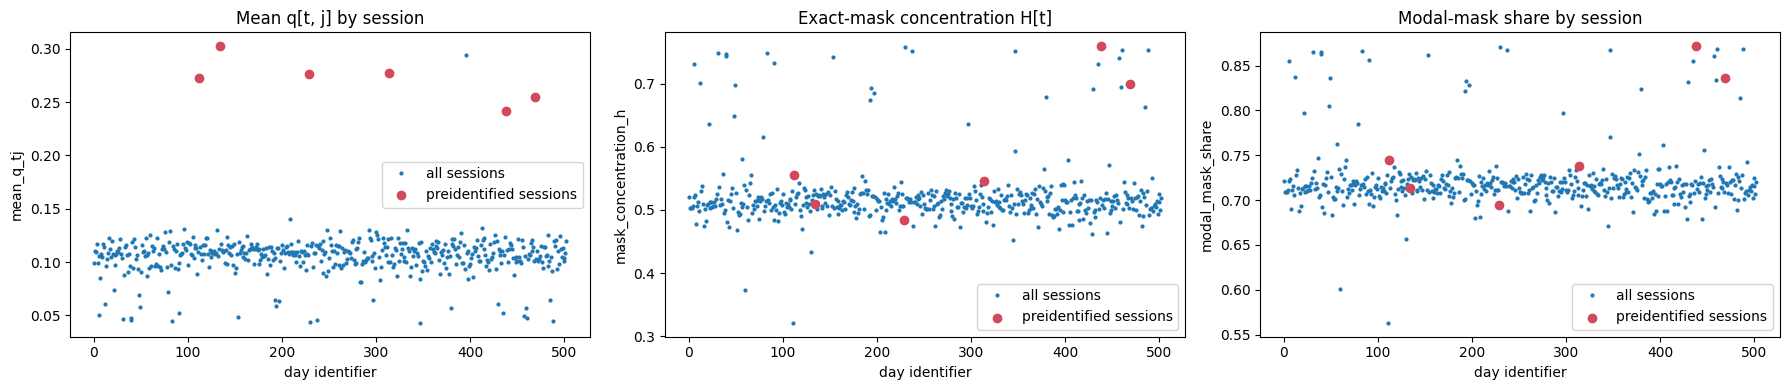

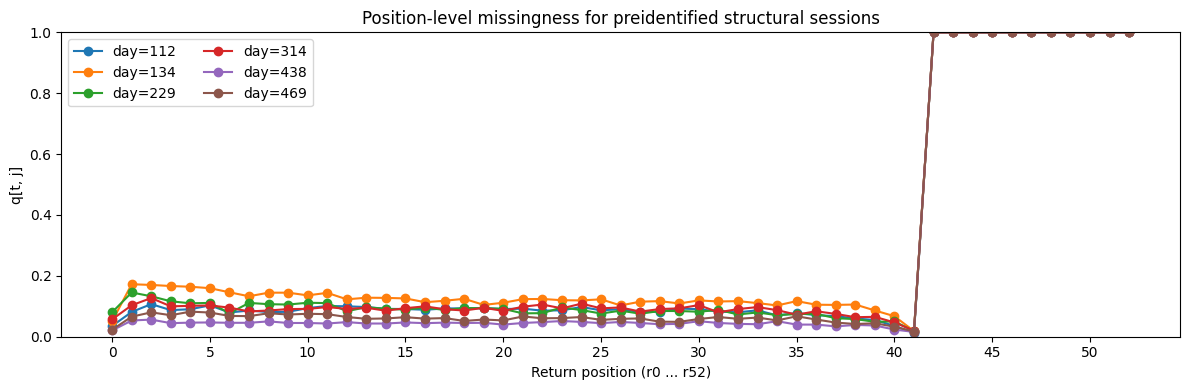

Interpretation boundary: H[t] is the probability that two rows share an exact mask. It is not, by itself, evidence of shared missingness when the modal mask is fully observed.


In [26]:
# Full-session comparison and fixed context for previously identified structural sessions.
preidentified_structural_days = (112, 134, 229, 314, 438, 469)
session_structure_summary = session_q_summary.join(session_mask_summary)
session_structure_summary['preidentified_dominant_mask_day'] = session_structure_summary.index.isin(preidentified_structural_days)
for metric in ('mean_q_tj', 'max_q_tj', 'mask_concentration_h', 'modal_mask_share', 'top_1_coverage', 'top_5_coverage', 'top_10_coverage'):
    session_structure_summary[f'{metric}_rank_desc'] = session_structure_summary[metric].rank(method='min', ascending=False).astype(int)
assert set(preidentified_structural_days).issubset(session_structure_summary.index)
display(session_structure_summary)
display(session_structure_summary.loc[list(preidentified_structural_days)])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for axis, metric, title in zip(
    axes,
    ('mean_q_tj', 'mask_concentration_h', 'modal_mask_share'),
    ('Mean q[t, j] by session', 'Exact-mask concentration H[t]', 'Modal-mask share by session'),
):
    axis.plot(session_structure_summary.index, session_structure_summary[metric], marker='o', linestyle='none', markersize=2, label='all sessions')
    highlighted = session_structure_summary.loc[list(preidentified_structural_days)]
    axis.scatter(highlighted.index, highlighted[metric], color='#d1495b', label='preidentified sessions', zorder=3)
    axis.set(title=title, xlabel='day identifier', ylabel=metric)
    axis.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for day in preidentified_structural_days:
    ax.plot(range(53), session_position_missingness.loc[day], marker='o', label=f'day={day}')
ax.set(title='Position-level missingness for preidentified structural sessions', xlabel='Return position (r0 ... r52)', ylabel='q[t, j]', ylim=(0, 1))
ax.set_xticks(range(0, 53, 5))
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print('Interpretation boundary: H[t] is the probability that two rows share an exact mask. It is not, by itself, evidence of shared missingness when the modal mask is fully observed.')

---

## Descriptive robustness: exact missing-count target composition excluding structural sessions

The exclusion set is fixed before consulting `reod`: `S = {112, 134, 229, 314, 438, 469}`. These are the six sessions established by the preceding target-free structural audit to have a modal cross-sectional mask with missingness, specifically `r42...r52 = NaN`. This comparison remains descriptive: it is not a production exclusion rule, OOS evaluation, or experiment.

In [27]:
# The session set is defined from the preceding target-free structural audit, before target aggregation.
structural_exclusion_days = (112, 134, 229, 314, 438, 469)
included_after_structural_exclusion = ~X_train['day'].isin(structural_exclusion_days)
assert set(structural_exclusion_days).issubset(set(X_train['day'].unique()))
assert included_after_structural_exclusion.sum() + (~included_after_structural_exclusion).sum() == len(X_train)

excluded_class_counts = (
    pd.crosstab(n_missing.loc[included_after_structural_exclusion], y_train.loc[included_after_structural_exclusion])
    .reindex(index=missing_count_levels, columns=classes, fill_value=0)
)
excluded_probabilities = excluded_class_counts.div(
    excluded_class_counts.sum(axis=1).replace(0, np.nan), axis=0
)

missing_count_exclusion_robustness = pd.DataFrame({
    'n_rows_pooled': missing_count_exact_table['n_rows'],
    'n_rows_excluding_S': excluded_class_counts.sum(axis=1),
    'p_reod_-1_pooled': missing_count_exact_table['p_reod_-1_given_n_missing'],
    'p_reod_0_pooled': missing_count_exact_table['p_reod_0_given_n_missing'],
    'p_reod_1_pooled': missing_count_exact_table['p_reod_1_given_n_missing'],
    'p_reod_-1_excluding_S': excluded_probabilities[-1],
    'p_reod_0_excluding_S': excluded_probabilities[0],
    'p_reod_1_excluding_S': excluded_probabilities[1],
})
for label, column in ((-1, 'p_reod_-1'), (0, 'p_reod_0'), (1, 'p_reod_1')):
    missing_count_exclusion_robustness[f'delta_{column}'] = (
        missing_count_exclusion_robustness[f'{column}_excluding_S']
        - missing_count_exclusion_robustness[f'{column}_pooled']
    )
missing_count_exclusion_robustness['p_directional_pooled'] = (
    missing_count_exclusion_robustness['p_reod_-1_pooled']
    + missing_count_exclusion_robustness['p_reod_1_pooled']
)
missing_count_exclusion_robustness['p_directional_excluding_S'] = (
    missing_count_exclusion_robustness['p_reod_-1_excluding_S']
    + missing_count_exclusion_robustness['p_reod_1_excluding_S']
)

assert missing_count_exclusion_robustness['n_rows_excluding_S'].le(missing_count_exclusion_robustness['n_rows_pooled']).all()
assert missing_count_exclusion_robustness['n_rows_pooled'].sum() == len(X_train)
assert missing_count_exclusion_robustness['n_rows_excluding_S'].sum() == included_after_structural_exclusion.sum()
nonempty_after_exclusion = missing_count_exclusion_robustness['n_rows_excluding_S'].gt(0)
assert np.allclose(
    missing_count_exclusion_robustness.loc[nonempty_after_exclusion, [
        'p_reod_-1_excluding_S', 'p_reod_0_excluding_S', 'p_reod_1_excluding_S'
    ]].sum(axis=1),
    1.0,
)
assert missing_count_exclusion_robustness.loc[~nonempty_after_exclusion, [
    'p_reod_-1_excluding_S', 'p_reod_0_excluding_S', 'p_reod_1_excluding_S'
]].isna().all().all()

display(missing_count_exclusion_robustness)
print(f'Rows excluded because day is in S: {(~included_after_structural_exclusion).sum():,}')
print('Levels empty after exclusion:', missing_count_exclusion_robustness.index[~nonempty_after_exclusion].tolist())


,n_rows_pooled,n_rows_excluding_S,p_reod_-1_pooled,p_reod_0_pooled,p_reod_1_pooled,p_reod_-1_excluding_S,p_reod_0_excluding_S,p_reod_1_excluding_S,delta_p_reod_-1,delta_p_reod_0,delta_p_reod_1,p_directional_pooled,p_directional_excluding_S
n_missing,,,,,,,,,,,,,
0,600936,600936,0.327131,0.358903,0.313965,0.327131,0.358903,0.313965,0.000000,0.000000,0.000000,0.641097,0.641097
1,24851,24851,0.360670,0.302121,0.337210,0.360670,0.302121,0.337210,0.000000,0.000000,0.000000,0.697879,0.697879
2,10448,10448,0.365142,0.285031,0.349828,0.365142,0.285031,0.349828,0.000000,0.000000,0.000000,0.714969,0.714969
3,8276,8276,0.364065,0.298212,0.337724,0.364065,0.298212,0.337724,0.000000,0.000000,0.000000,0.701788,0.701788
4,7199,7199,0.351577,0.308237,0.340186,0.351577,0.308237,0.340186,0.000000,0.000000,0.000000,0.691763,0.691763
5,6543,6543,0.352896,0.325233,0.321871,0.352896,0.325233,0.321871,0.000000,0.000000,0.000000,0.674767,0.674767
6,6135,6135,0.340016,0.326161,0.333822,0.340016,0.326161,0.333822,0.000000,0.000000,0.000000,0.673839,0.673839
7,5798,5798,0.332701,0.343049,0.324250,0.332701,0.343049,0.324250,0.000000,0.000000,0.000000,0.656951,0.656951
8,5484,5484,0.329504,0.353392,0.317104,0.329504,0.353392,0.317104,0.000000,0.000000,0.000000,0.646608,0.646608


Rows excluded because day is in S: 10,146
Levels empty after exclusion: []


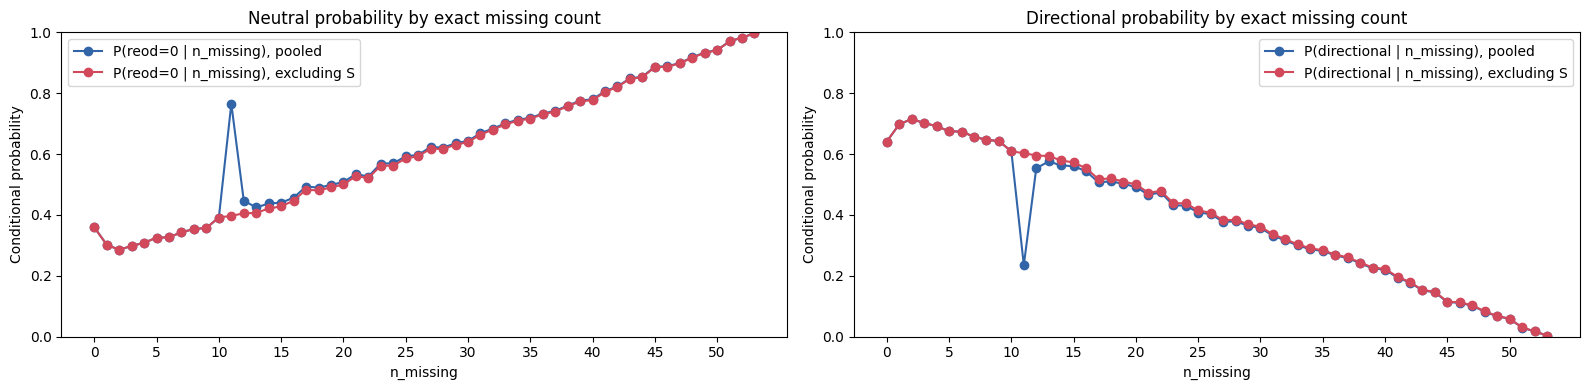

Interpretation boundary: this is a robustness description of the pooled association after removing a structurally identified session set; it does not validate a future-session exclusion policy.


In [28]:
# Exact integer levels only: no smoothing, bins, or threshold selection.
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for column, label, color in (
    ('p_reod_0_pooled', 'P(reod=0 | n_missing), pooled', '#3264a8'),
    ('p_reod_0_excluding_S', 'P(reod=0 | n_missing), excluding S', '#d1495b'),
):
    axes[0].plot(missing_count_exclusion_robustness.index, missing_count_exclusion_robustness[column], marker='o', label=label, color=color)
axes[0].set(title='Neutral probability by exact missing count', xlabel='n_missing', ylabel='Conditional probability', ylim=(0, 1))
axes[0].set_xticks(range(0, 54, 5))
axes[0].legend()

for column, label, color in (
    ('p_directional_pooled', 'P(directional | n_missing), pooled', '#3264a8'),
    ('p_directional_excluding_S', 'P(directional | n_missing), excluding S', '#d1495b'),
):
    axes[1].plot(missing_count_exclusion_robustness.index, missing_count_exclusion_robustness[column], marker='o', label=label, color=color)
axes[1].set(title='Directional probability by exact missing count', xlabel='n_missing', ylabel='Conditional probability', ylim=(0, 1))
axes[1].set_xticks(range(0, 54, 5))
axes[1].legend()
plt.tight_layout()
plt.show()

print('Interpretation boundary: this is a robustness description of the pooled association after removing a structurally identified session set; it does not validate a future-session exclusion policy.')
